# Figure 6. The Human Heart Cell Atlas is used to improve our understading ofcytokine and drug targeting in heart transplant rejection a-b, UMAP embeddings of T a

11 panels of this figure are built below, one section each.

---

## Setup

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina']
import sys
sys.path[:0] = ["../src", "../figures/_lib", "../figures/Fig6"]
from hhca.paths import TABLES, OUT
print('inputs :', TABLES)
print('outputs:', OUT)

inputs : /Volumes/Storage/hhca_spatial_tables
outputs: /Users/maiia.shulman/hhca_release_out


## Fig6 c

Fig 6c — whole-slide Xenium TMA with HHCA-transferred immune labels, lymphoid at Level 4, one high-grade zoom (heart_l4_recovery/panel_c_tma_L4_all.py).

Input:
- `heart_results/rejection_prediction/tables/{xenium_atlas_labels,xenium_lymphoid8_annotation}.csv`
- `storage/rejection_GSE290577/extracted/cells_geom.csv`

Source: `figures/Fig6/panel_c.py`

slide: slide2 | zoom biopsy: Patient_54_1 grade 3.0
counts: {'Macrophages': 4342, 'Monocytes': 4996, 'Dendritic cells': 3293, 'B cells': 3047, 'Plasma Cells': 2888, 'Mast cells': 1153, 'CD8 T cells': 5431, 'Proliferating CD8 T cells': 2076, 'CD4 T cells': 3285, 'Proliferating CD4 T cells': 862, 'Tregs': 653, 'Proliferating Tregs': 190, 'NK cells': 1343, 'Proliferating NK cells': 513}


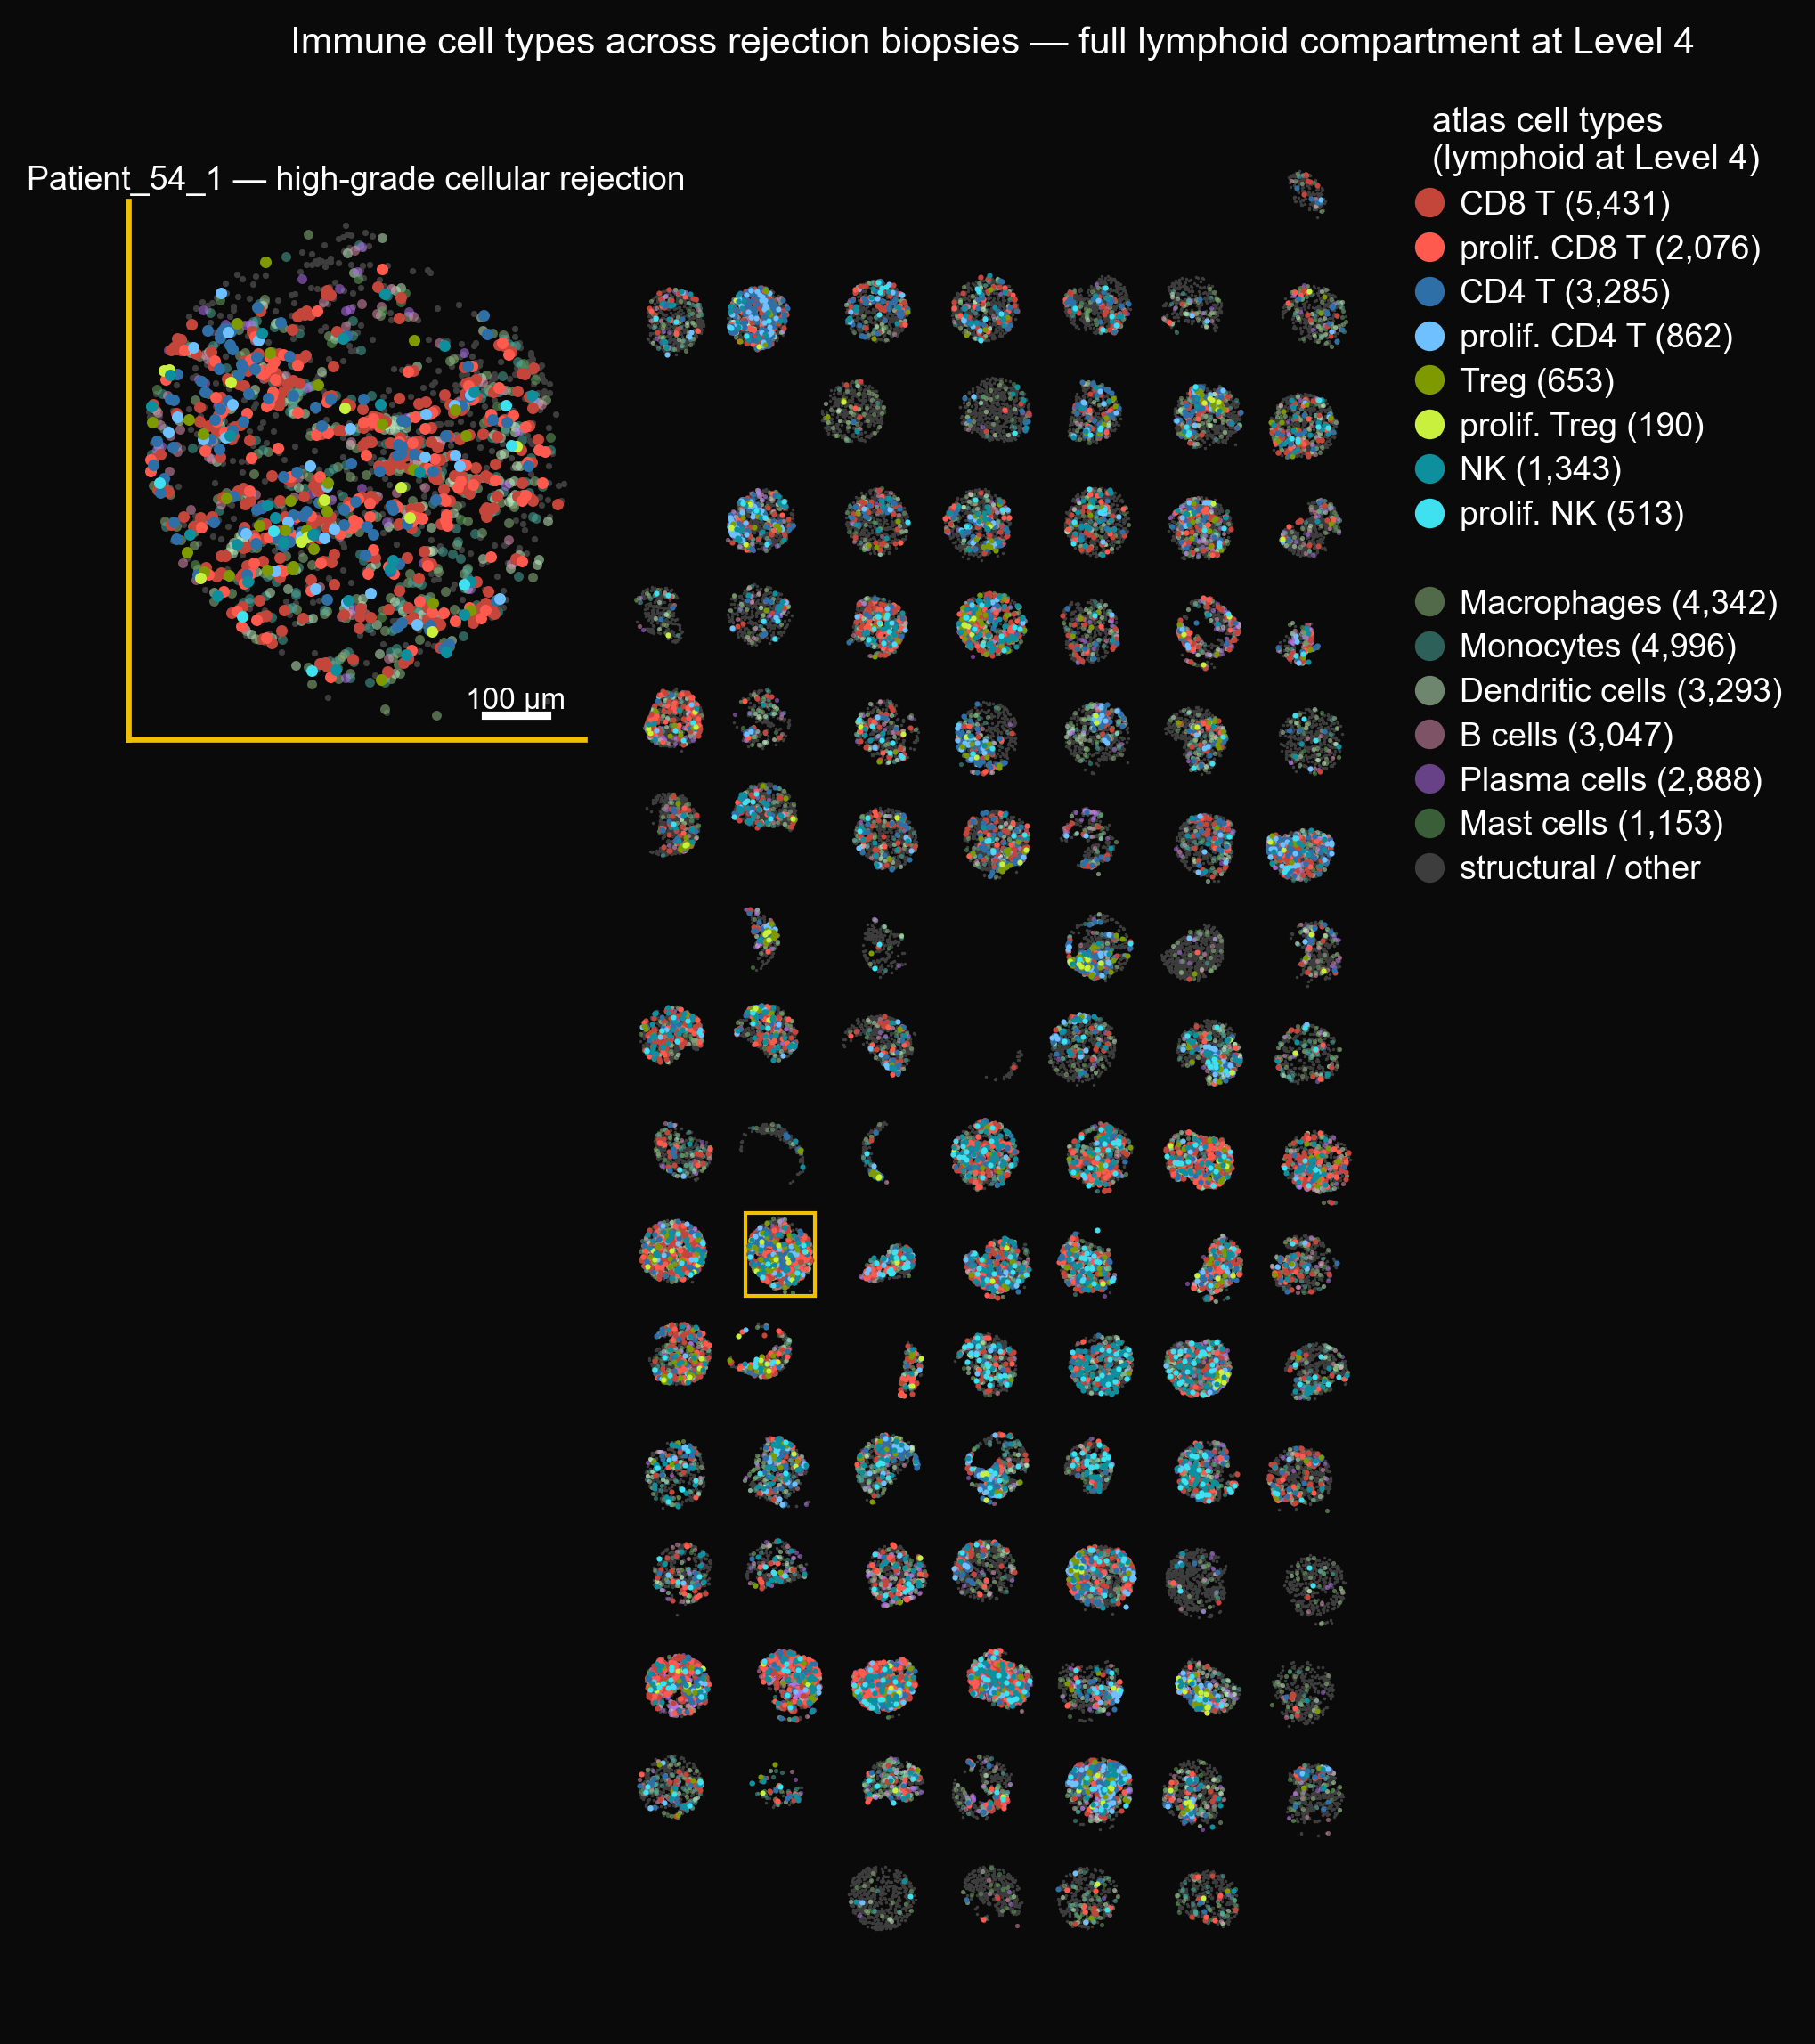

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from hhca.paths import TABLES
from hhca import style as H
from pubfig import save

H.apply()
TAB = f"{TABLES}/heart_results/rejection_prediction/tables/"
GEO = f"{TABLES}/storage/rejection_GSE290577/extracted/cells_geom.csv"
BG = "#0a0a0a"; STRUCT = "#3d3d3d"

LYM_COL = {
    "CD8 T cells": "#C4453A", "Proliferating CD8 T cells": "#FF5A4D",
    "CD4 T cells": "#2E6FA8", "Proliferating CD4 T cells": "#6FC0FF",
    "Tregs": "#7F9A00", "Proliferating Tregs": "#C8F03C",
    "NK cells": "#0E8F9E", "Proliferating NK cells": "#3FE0F0",
}
LYM = list(LYM_COL)
OTHER = ["Macrophages", "Monocytes", "Dendritic cells", "B cells", "Plasma Cells", "Mast cells"]
ORDER = OTHER + LYM
DISP = {"Plasma Cells": "Plasma cells",
        "CD8 T cells": "CD8 T", "CD4 T cells": "CD4 T", "Tregs": "Treg", "NK cells": "NK",
        "Proliferating CD8 T cells": "prolif. CD8 T", "Proliferating CD4 T cells": "prolif. CD4 T",
        "Proliferating Tregs": "prolif. Treg", "Proliferating NK cells": "prolif. NK"}


def col(n):
    return LYM_COL[n] if n in LYM_COL else H.ct(n)


lab = pd.read_csv(TAB + "xenium_atlas_labels.csv",
                  usecols=["cell_id", "Sample", "atlas_L3", "slide", "biopsy_cellular_grading"])
l8 = pd.read_csv(TAB + "xenium_lymphoid8_annotation.csv", usecols=["cell_id", "label8"])
g = pd.read_csv(GEO, usecols=["cell_id", "Sample", "x_centroid", "y_centroid"])
g = g.merge(lab, on=["cell_id", "Sample"], how="inner").merge(l8, on="cell_id", how="left")
slide = g.groupby("slide").Sample.nunique().idxmax()
gs = g[g.slide == slide].copy()
gs["disp"] = np.where(gs.label8.notna(), gs.label8,
                      np.where(gs.atlas_L3.isin(OTHER), gs.atlas_L3, None))
gs["is_imm"] = gs.disp.notna()
cand = pd.DataFrame({"grade": gs.groupby("Sample").biopsy_cellular_grading.first(),
                     "nimm": gs.groupby("Sample").is_imm.sum()}).dropna()
ZOOM = cand.sort_values(["grade", "nimm"], ascending=False).index[0]
print("slide:", slide, "| zoom biopsy:", ZOOM, "grade", cand.loc[ZOOM, "grade"])

fig, ax = plt.subplots(figsize=(6.8, 9.4))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)


def draw(axx, frame, ss_bg, ss):
    b = frame[frame.disp.isna()]
    axx.scatter(b.x_centroid, b.y_centroid, s=ss_bg, c=STRUCT, linewidths=0, rasterized=True, zorder=1)
    for name in ORDER:
        s2 = frame[frame.disp == name]
        if not len(s2):
            continue
        lym = name in LYM_COL
        axx.scatter(s2.x_centroid, s2.y_centroid, s=ss * (1.3 if lym else 0.92),
                    c=col(name), alpha=1.0 if lym else 0.55, linewidths=0,
                    rasterized=True, zorder=3 if lym else 2)


counts = {n: int((gs.disp == n).sum()) for n in ORDER}
draw(ax, gs, 0.7, 1.7)
ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")

zs = gs[gs.Sample == ZOOM]
axz = ax.inset_axes([-0.60, 0.63, 0.58, 0.34]); axz.set_facecolor(BG)
draw(axz, zs, 3.0, 7.5)
axz.set_aspect("equal"); axz.invert_yaxis(); axz.set_xticks([]); axz.set_yticks([])
for sp in axz.spines.values():
    sp.set_color("#f0c000"); sp.set_linewidth(1.6)
zx0, zx1 = zs.x_centroid.min(), zs.x_centroid.max(); zsb = 100.0
axz.plot([zx1 - zsb - 0.04 * (zx1 - zx0), zx1 - 0.04 * (zx1 - zx0)],
         [zs.y_centroid.max()] * 2, color="white", lw=2.2)
axz.text(zx1 - 0.04 * (zx1 - zx0) - zsb / 2, zs.y_centroid.max(), "100 µm",
         color="white", fontsize=8, ha="center", va="bottom")
axz.set_title(f"{ZOOM} — high-grade cellular rejection", fontsize=9, color="white", pad=3)
_r, _c1, _c2 = mark_inset(ax, axz, loc1=2, loc2=3, fc="none", ec="#f0c000", lw=1.0)
_c1.set_visible(False); _c2.set_visible(False)

handles = [Line2D([0], [0], marker="o", ls="", mfc=col(n), mec="none", ms=8,
                  label=f"{DISP.get(n, n)} ({counts[n]:,})") for n in LYM if counts[n] > 0]
handles.append(Line2D([0], [0], marker="", ls="", label=""))
handles += [Line2D([0], [0], marker="o", ls="", mfc=col(n), mec="none", ms=8, alpha=0.55,
                   label=f"{DISP.get(n, n)} ({counts[n]:,})") for n in OTHER if counts[n] > 0]
handles.append(Line2D([0], [0], marker="o", ls="", mfc=STRUCT, mec="none", ms=8, label="structural / other"))
leg = ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=9,
                handletextpad=0.3, labelspacing=0.42, title="atlas cell types\n(lymphoid at Level 4)",
                title_fontsize=9.5, facecolor=BG, edgecolor="none")
for t in leg.get_texts():
    t.set_color("white")
leg.get_title().set_color("white")
ax.set_title("Immune cell types across rejection biopsies — full lymphoid compartment at Level 4",
             fontsize=10.2, pad=8, color="white")
print("counts:", counts)
save(fig, "Fig6", "c", bbox_inches="tight", facecolor=BG)


## Fig6 d

Fig 6d — pre-treatment biopsy overview: clinical tracks, immune fraction, foci, largest focus, Level-4 immune composition (heart_l4_recovery/panel_d_prolif_resolved.py pre).

Input:
- `heart_results/manuscript_restyle/Fig6/atlas_tables/amr_axis_features_ATLAS.csv`
- `heart_results/rejection_prediction/tables/{predict_next_transitions,xenium_atlas_labels,xenium_lymphoid8_annotation}.csv`

Source: `figures/Fig6/panel_d.py`

biopsies: 80 | per patient-type: {'cellular_rejection': 54, 'mixed_rejection': 15, 'antibody_rejection': 11}


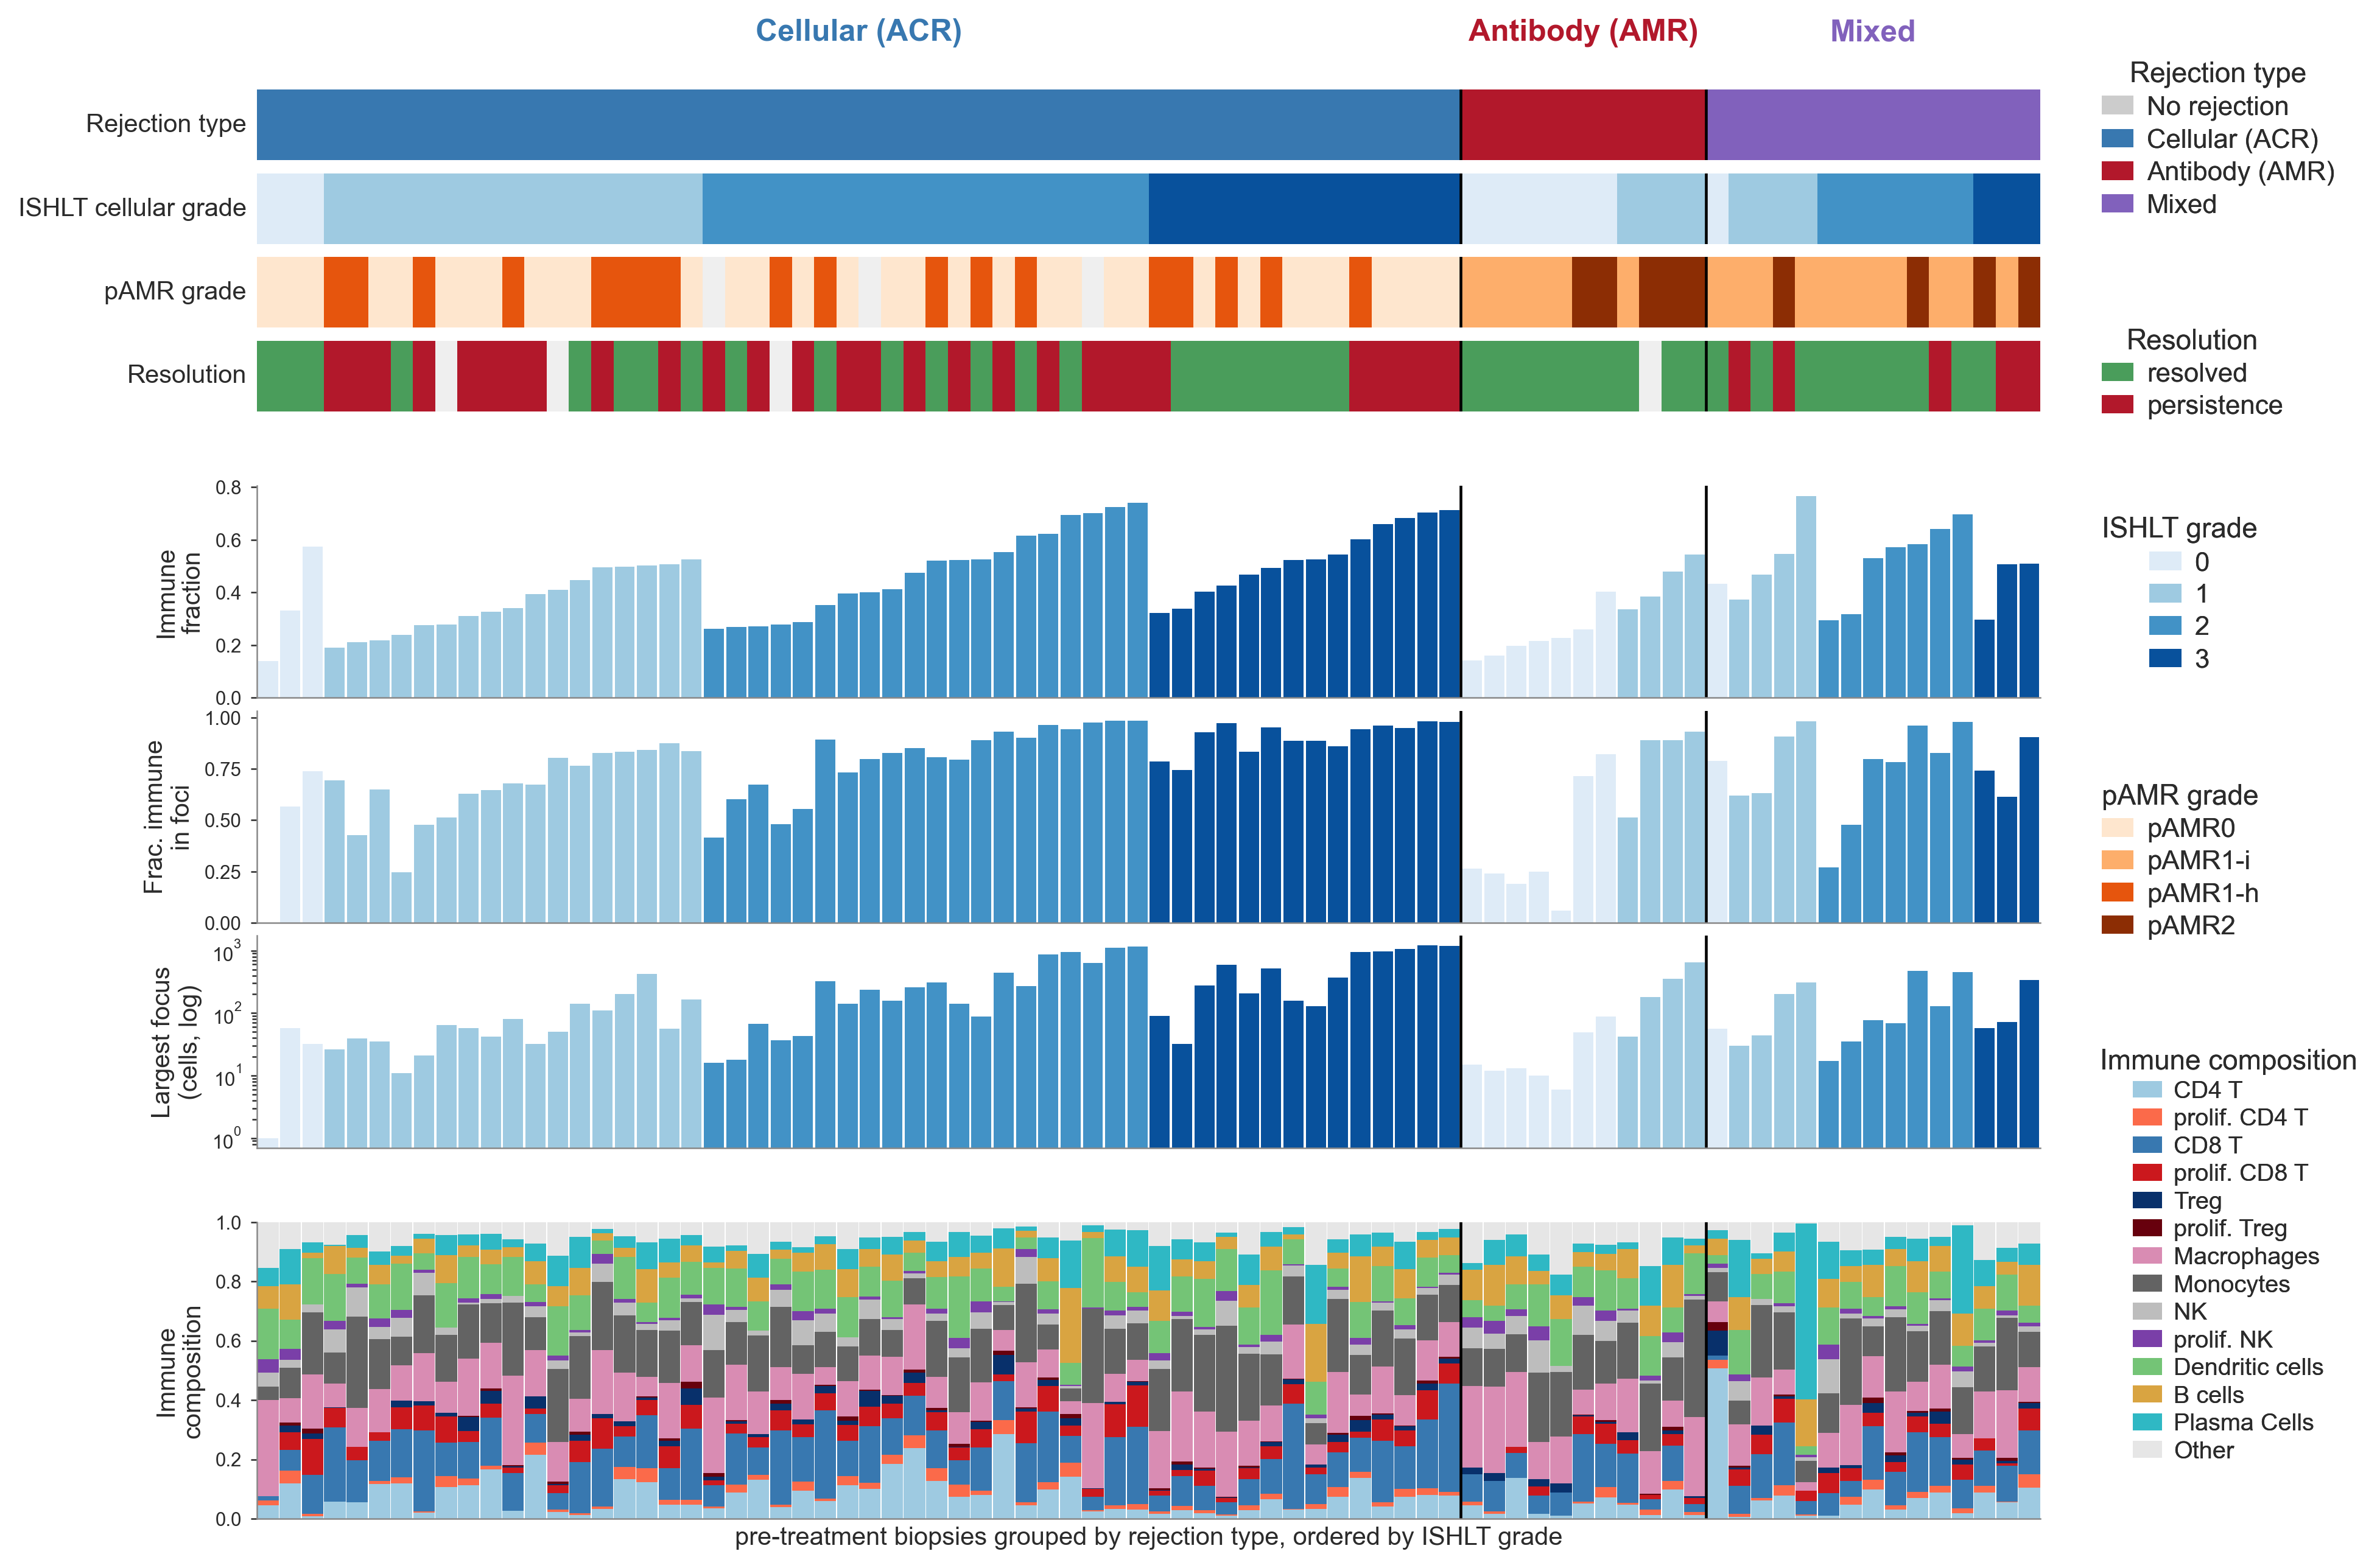

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from hhca.paths import TABLES
from hhca import style as H
from pubfig import save

H.apply()
SRC = f"{TABLES}/heart_results/manuscript_restyle/Fig6"
TAB = f"{TABLES}/heart_results/rejection_prediction/tables/"
TIMING = "pre"
FIG, PANEL = "Fig6", "d"

d = pd.read_csv(SRC + "/atlas_tables/amr_axis_features_ATLAS.csv")
d = d.dropna(subset=["biopsy_cellular_grading", "dbscan_frac_in_agg"]).copy()
d["g"] = d.biopsy_cellular_grading.astype(int)
d["rej"] = d.biopsy_rejection_type.astype(str).str.strip()
d["pamr"] = d.biopsy_antibody_grading.astype(str).str.strip()
d["largest_cells"] = (d.dbscan_largest_agg_frac * d.n_immune).clip(lower=1)
pt = pd.read_csv(TAB + "predict_next_transitions.csv")
res = {r.cur_Sample: ("resolved" if r.next_grade < 2 else "persistence") for r in pt.itertuples()}
d["res"] = d.Sample.map(res).fillna("na")

lab = pd.read_csv(TAB + "xenium_atlas_labels.csv", usecols=["cell_id", "Sample", "atlas_L3"])
l8 = pd.read_csv(TAB + "xenium_lymphoid8_annotation.csv", usecols=["cell_id", "label8"])
lab = lab.merge(l8, on="cell_id", how="left")
L8MAP = {"CD4 T cells": "CD4 T", "CD8 T cells": "CD8 T", "Tregs": "Treg", "NK cells": "NK",
         "Proliferating CD4 T cells": "prolif. CD4 T", "Proliferating CD8 T cells": "prolif. CD8 T",
         "Proliferating Tregs": "prolif. Treg", "Proliferating NK cells": "prolif. NK"}
L3MAP = {"Macrophages": "Macrophages", "Monocytes": "Monocytes", "Dendritic cells": "Dendritic cells",
         "B cells": "B cells", "Plasma Cells": "Plasma Cells", "Mast cells": "Other", "ILC": "Other"}
lab["cat"] = np.where(lab.label8.notna(), lab.label8.map(L8MAP), lab.atlas_L3.map(L3MAP))
imm = lab[lab.cat.notna()]
COMP = ["CD4 T", "prolif. CD4 T", "CD8 T", "prolif. CD8 T", "Treg", "prolif. Treg",
        "Macrophages", "Monocytes", "NK", "prolif. NK", "Dendritic cells", "B cells",
        "Plasma Cells", "Other"]
comp = pd.crosstab(imm.Sample, imm.cat, normalize="index").reindex(columns=COMP).fillna(0.0)
nimm = imm.groupby("Sample").size()

meta = pd.read_csv(TAB + "xenium_atlas_labels.csv",
                   usecols=["Sample", "patient_rejection_type", "biopsy_timing"]).drop_duplicates("Sample").set_index("Sample")
d["prt"] = d.Sample.map(meta["patient_rejection_type"]).astype(str).str.strip()
REJO = ["cellular_rejection", "antibody_rejection", "mixed_rejection"]
d = d[d.prt.isin(REJO)].copy()
d = d[d.Sample.map(meta["biopsy_timing"]).astype(str).str.strip() == TIMING].copy()
d = d[d.Sample.isin(comp.index[nimm.reindex(comp.index).fillna(0) >= 25])]
d["ro"] = d.prt.map({k: i for i, k in enumerate(REJO)})
d = d.sort_values(["ro", "g", "immune_fraction"]).reset_index(drop=True)
comp = comp.loc[d.Sample.values]
n = len(d)
print("biopsies:", n, "| per patient-type:", d.prt.value_counts().to_dict())
bnd = np.where(np.diff(d.ro.values) != 0)[0] + 0.0

GR = ["#deebf7", "#9ecae1", "#4292c6", "#08519c"]
REJ_C = {"no_rejection": "#cccccc", "cellular_rejection": "#3878b0",
         "antibody_rejection": "#B2182B", "mixed_rejection": "#8161bc"}
PAMR = ["pAMR0", "pAMR1-i", "pAMR1-h", "pAMR2"]
PAMR_C = dict(zip(PAMR, ["#fee6ce", "#fdae6b", "#e6550d", "#8c2d04"]))
RES_C = {"resolved": "#4a9d5b", "persistence": "#B2182B", "na": "#efefef"}
COMP_C = {"CD4 T": "#9ecae1", "prolif. CD4 T": "#fb6a4a", "CD8 T": "#3878b0",
          "prolif. CD8 T": "#cb181d", "Treg": "#08306b", "prolif. Treg": "#67000d",
          "Macrophages": "#d98cb3", "Monocytes": "#636363", "NK": "#bdbdbd",
          "prolif. NK": "#7a3fa8", "Dendritic cells": "#74c476", "B cells": "#d9a441",
          "Plasma Cells": "#2fb8c4", "Other": "#e6e6e6"}

fig = plt.figure(figsize=(15.5, 8.6))
gs = gridspec.GridSpec(10, 1, height_ratios=[0.5, 0.5, 0.5, 0.5, 0.34, 1.5, 1.5, 1.5, 0.34, 2.1],
                       hspace=0.10, left=0.12, right=0.75, top=0.96, bottom=0.05)


def strip(ax, vals, cmap, label):
    for i, v in enumerate(vals):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1,
                     fc=(cmap.get(v, "#efefef") if isinstance(cmap, dict) else cmap[int(v)]), ec="none"))
    ax.set_xlim(0, n); ax.set_ylim(0, 1); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_ylabel(label, rotation=0, ha="right", va="center", fontsize=10)
    for b in bnd:
        ax.axvline(b + 1, color="k", lw=1.1)


axs = [fig.add_subplot(gs[i]) for i in range(4)]
strip(axs[0], d.prt.values, REJ_C, "Rejection type")
strip(axs[1], d.g.values, GR, "ISHLT cellular grade")
strip(axs[2], d.pamr.values, PAMR_C, "pAMR grade")
strip(axs[3], d.res.values, RES_C, "Resolution")
for grp, lab_ in [("cellular_rejection", "Cellular (ACR)"), ("antibody_rejection", "Antibody (AMR)"),
                  ("mixed_rejection", "Mixed")]:
    idx = np.where(d.prt.values == grp)[0]
    if len(idx):
        axs[0].text((idx.min() + idx.max()) / 2 + 0.5, 1.6, lab_, ha="center", va="bottom",
                    fontsize=12, fontweight="bold", color=REJ_C[grp])


def bars(ax, vals, label, logy=False):
    ax.bar(np.arange(n) + 0.5, vals, width=0.9, color=[GR[gg] for gg in d.g.values], edgecolor="none")
    ax.set_xlim(0, n); ax.set_xticks([])
    if logy:
        ax.set_yscale("log")
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.set_ylabel(label, fontsize=10)
    for b in bnd:
        ax.axvline(b + 1, color="k", lw=1.1)


bars(fig.add_subplot(gs[5]), d.immune_fraction.values, "Immune\nfraction")
bars(fig.add_subplot(gs[6]), d.dbscan_frac_in_agg.values, "Frac. immune\nin foci")
bars(fig.add_subplot(gs[7]), d.largest_cells.values, "Largest focus\n(cells, log)", logy=True)

axc = fig.add_subplot(gs[9]); bottom = np.zeros(n)
for ct in COMP:
    v = comp[ct].values
    axc.bar(np.arange(n) + 0.5, v, bottom=bottom, width=0.96, color=COMP_C[ct], edgecolor="none")
    bottom += v
axc.set_xlim(0, n); axc.set_ylim(0, 1); axc.set_xticks([])
axc.set_ylabel("Immune\ncomposition", fontsize=10)
for sp in ("top", "right"):
    axc.spines[sp].set_visible(False)
for b in bnd:
    axc.axvline(b + 1, color="k", lw=1.1)
axc.set_xlabel(f"{TIMING}-treatment biopsies grouped by rejection type, ordered by ISHLT grade",
               fontsize=10, labelpad=3)

L = [("Rejection type", [Patch(fc=REJ_C[k], label=v) for k, v in
      [("no_rejection", "No rejection"), ("cellular_rejection", "Cellular (ACR)"),
       ("antibody_rejection", "Antibody (AMR)"), ("mixed_rejection", "Mixed")]], 0.99),
     ("Resolution", [Patch(fc=RES_C["resolved"], label="resolved"),
                     Patch(fc=RES_C["persistence"], label="persistence")], 0.82),
     ("ISHLT grade", [Patch(fc=GR[i], label=str(i)) for i in range(4)], 0.70),
     ("pAMR grade", [Patch(fc=PAMR_C[k], label=k) for k in PAMR], 0.53),
     ("Immune composition", [Patch(fc=COMP_C[c], label=c) for c in COMP], 0.36)]
for title, handles, y in L:
    fs = 9.5 if title == "Immune composition" else 10.5
    lg = fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.765, y), fontsize=fs,
                    title=title, title_fontsize=11, handlelength=1.2, handletextpad=0.5,
                    labelspacing=0.24 if title == "Immune composition" else 0.3, frameon=False)
    fig.add_artist(lg)
save(fig, FIG, PANEL, bbox_inches="tight")


## Fig6 e

Fig 6e — fraction of immune cells in DBSCAN foci vs per-core ISHLT cellular grade, TMA-core level (fig6_v9_e_samplelevel.py).

Input:
- `heart_results/rejection_prediction/tables/xenium_atlas_labels.csv`
- `heart_results/rejection_prediction/tables/geom_features_L4.csv`

Source: `figures/Fig6/panel_e.py`

cores n=188 | Spearman rho=0.667 p=1.48e-25


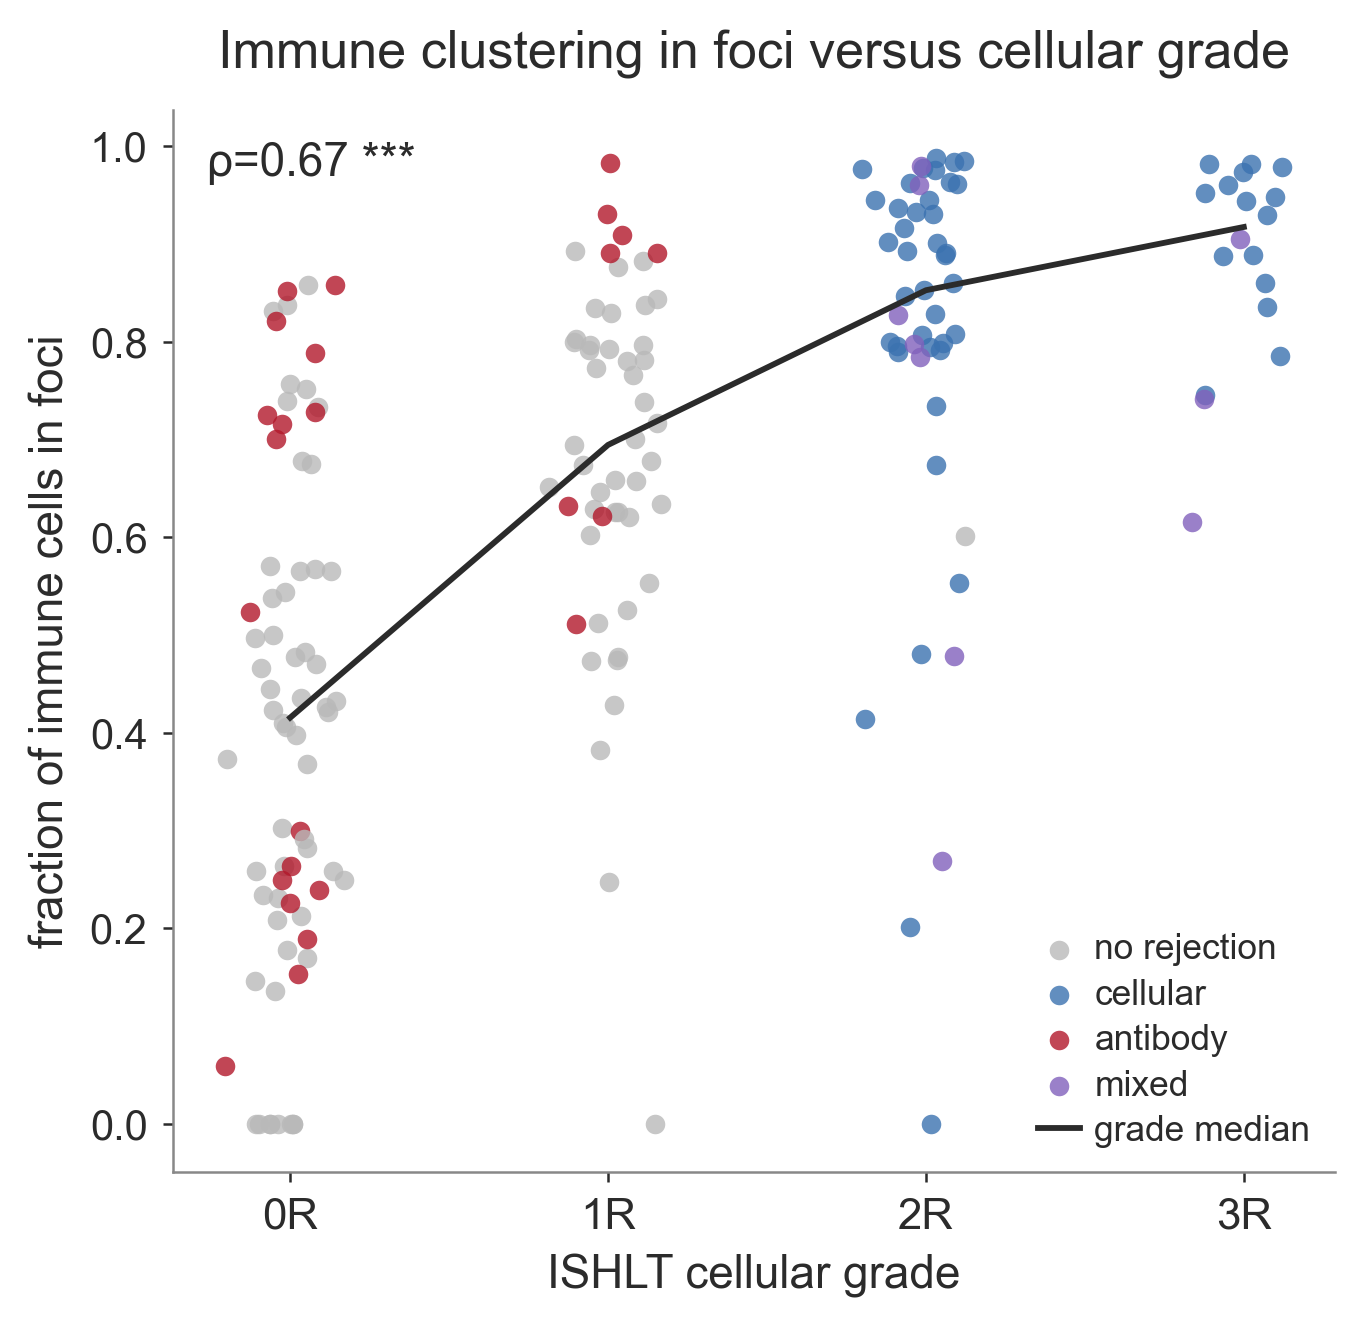

In [4]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from hhca import style as H
from pubfig import save
import fig6_cohort as C

C.apply_style()
RLAB = {"no_rejection": "no rejection", "cellular_rejection": "cellular",
        "antibody_rejection": "antibody", "mixed_rejection": "mixed"}
lab = pd.read_csv(C.TAB + "xenium_atlas_labels.csv",
                  usecols=["Sample", "biopsy_cellular_grading",
                           "biopsy_rejection_type"]).drop_duplicates("Sample").set_index("Sample")
lab["grade"] = pd.to_numeric(lab.biopsy_cellular_grading, errors="coerce")
lab["rej"] = lab.biopsy_rejection_type.astype(str).str.strip().replace("nan", np.nan)
geo = pd.read_csv(C.TAB + "geom_features_L4.csv").set_index("Sample")
d = pd.DataFrame({"grade": lab.grade, "rej": lab.rej,
                  "ff": geo.dbscan_frac_in_agg}).dropna(subset=["grade", "ff"])
rho, p = stats.spearmanr(d.grade, d.ff)
print(f"cores n={len(d)} | Spearman rho={rho:.3f} p={p:.3g}")

fig, ax = plt.subplots(figsize=(5.0, 4.6))
rng = np.random.default_rng(0)
for r in C.REJ4:
    s = d[d.rej == r]
    if not len(s):
        continue
    ax.scatter(s.grade + rng.normal(0, .085, len(s)), s.ff, s=22, color=C.RCOL[r],
               alpha=.8, linewidths=0, label=RLAB[r])
na = d[d.rej.isna()]
if len(na):
    ax.scatter(na.grade + rng.normal(0, .085, len(na)), na.ff, s=22, color="#B9B9B9",
               alpha=.8, linewidths=0)
me = d.groupby("grade").ff.median()
ax.plot(me.index, me.values, color=H.INK, lw=1.4, zorder=5, label="grade median")
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(["0R", "1R", "2R", "3R"])
ax.set_xlabel("ISHLT cellular grade")
ax.set_ylabel("fraction of immune cells in foci")
ax.text(.03, .97, f"ρ={rho:.2f} {H.stars(p)}", transform=ax.transAxes, va="top", fontsize=11)
ax.set_title("Immune clustering in foci versus cellular grade", fontsize=12.5, pad=10)
ax.legend(frameon=False, fontsize=8.5, loc="lower right", handletextpad=.4, labelspacing=.35)
for s_ in ("top", "right"):
    ax.spines[s_].set_visible(False)
save(fig, "Fig6", "e", bbox_inches="tight")


## Fig6 f, g

Fig 6f/6g — immune fraction (f) and T-cell fraction (g) before/after therapy, resolved vs persistence (fig6_v9.py).

Input:
- `see fig6_cohort.py`

Source: `figures/Fig6/panel_fg.py`

COHORT: 108 biopsies / 62 patients; core-negative excluded from rejection-labelled panels: 8
6f/6g [patients with a pre AND a post biopsy]: n=46 patients
   6f resolved: n=26, median 0.509 -> 0.303, p=9.15e-06
   6f persistence: n=20, median 0.403 -> 0.382, p=0.294
   6g resolved: n=26, median 0.152 -> 0.070, p=7.02e-05
   6g persistence: n=20, median 0.114 -> 0.152, p=0.898


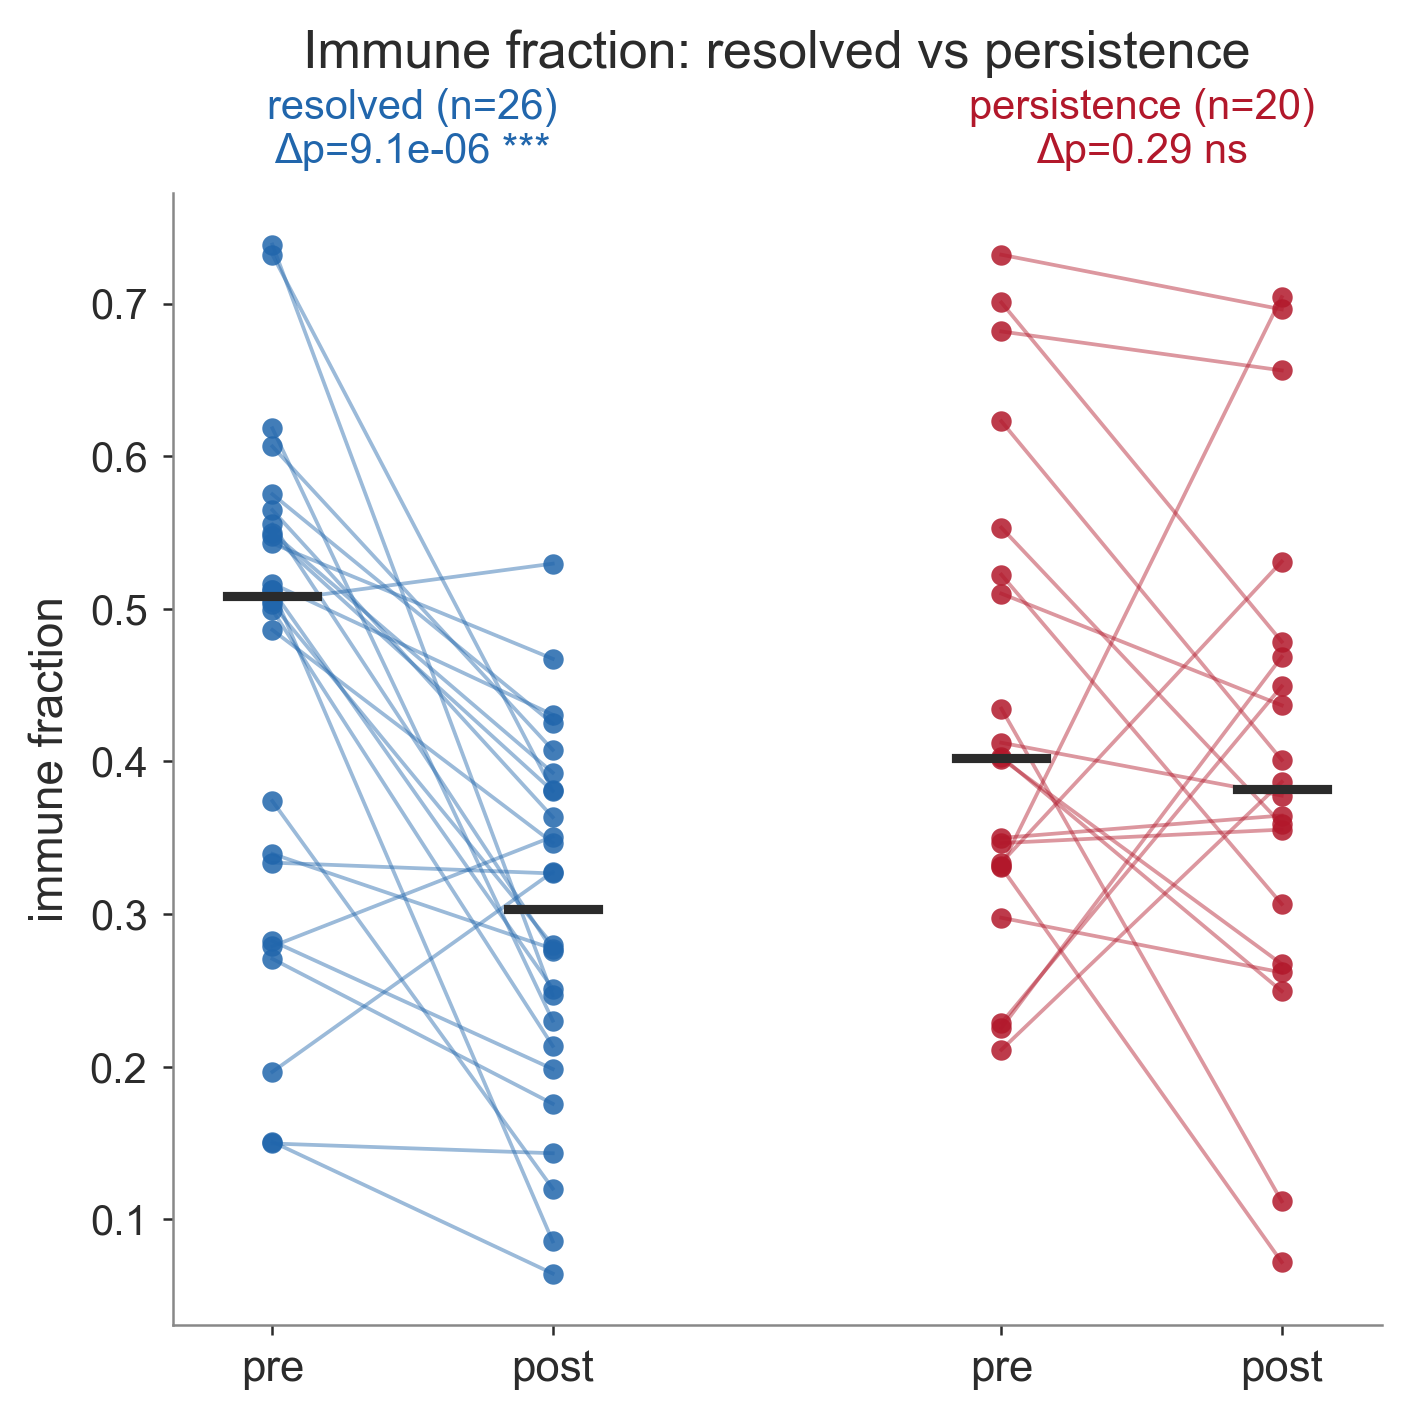

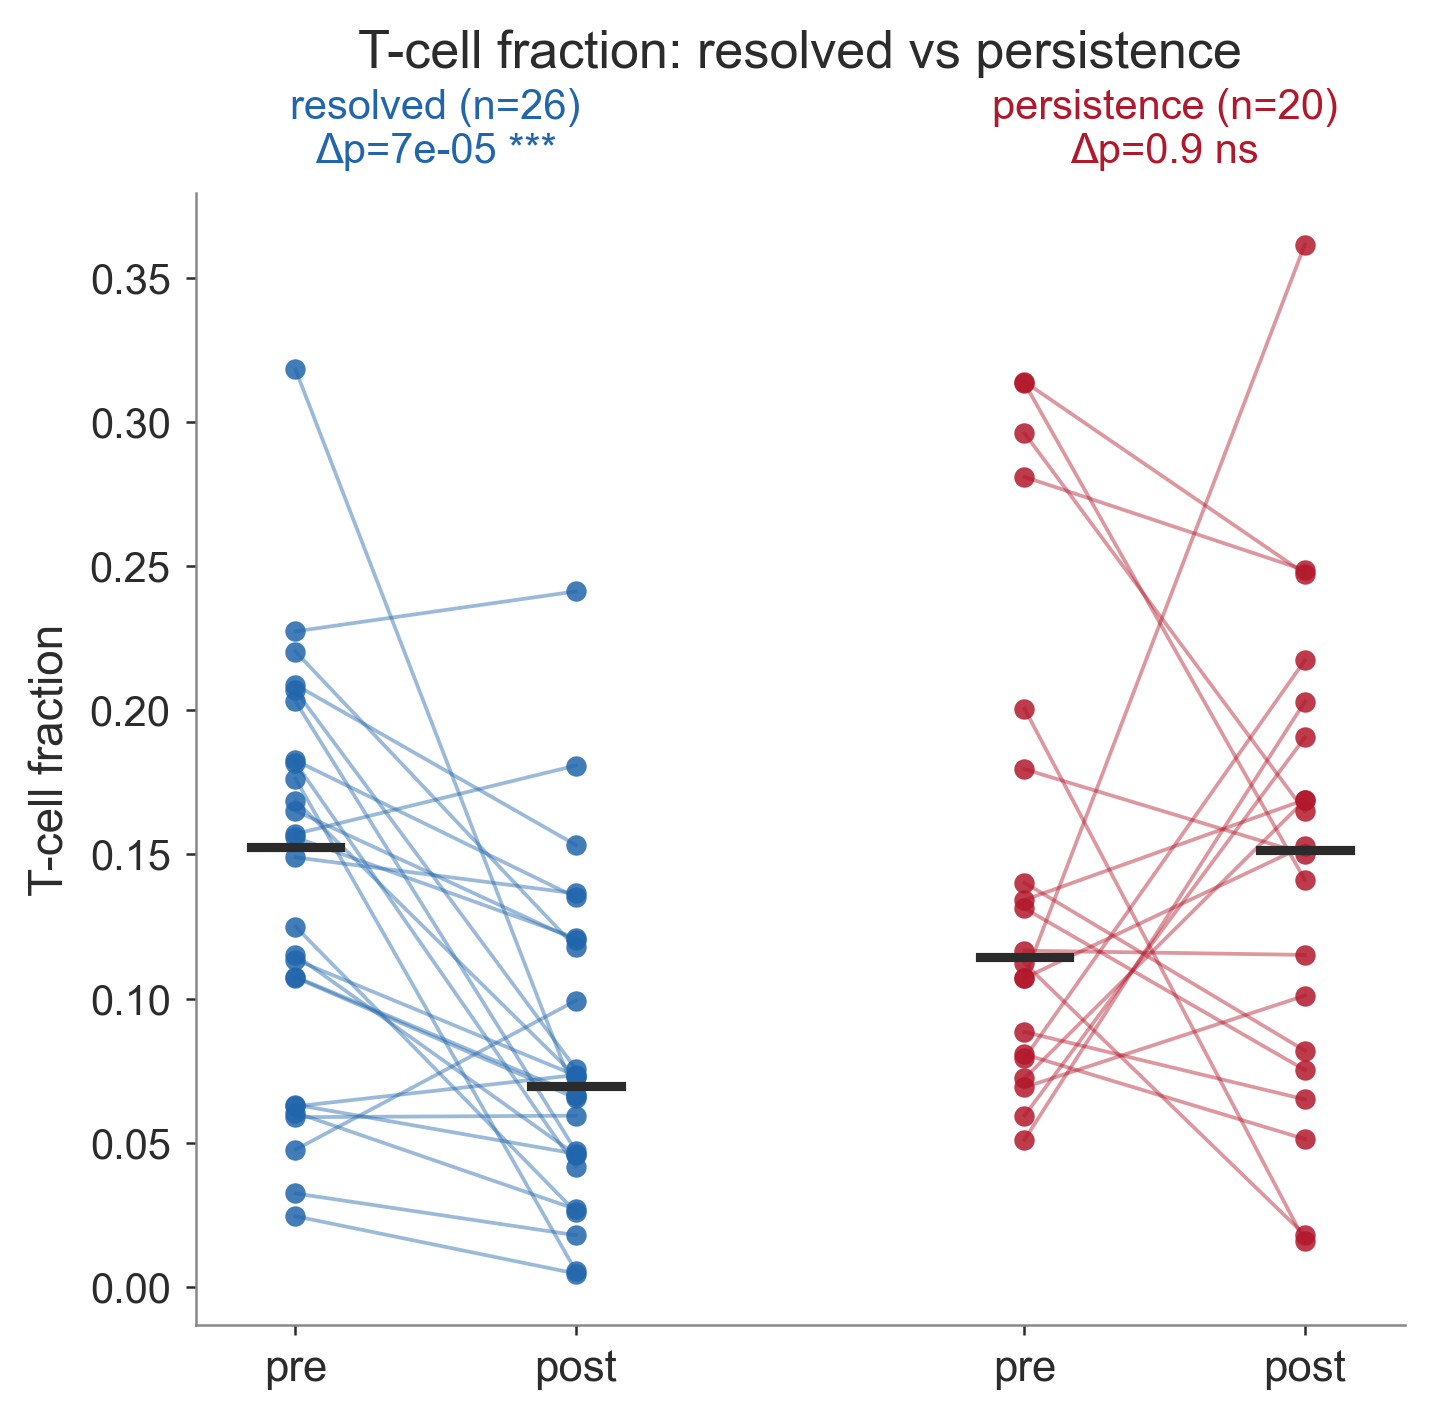

In [5]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from hhca import style as H
from pubfig import save
import fig6_cohort as C

C.apply_style()
c, M, cyto = C.cohort()
P = M.dropna(subset=["res"])
pre = P[P.timing == "pre"].set_index("patient")
post = P[P.timing == "post"].set_index("patient")
both = sorted(set(pre.index) & set(post.index))
print(f"6f/6g [patients with a pre AND a post biopsy]: n={len(both)} patients")
for fc, ylab, tag in [("immf", "immune fraction", "f"), ("tf", "T-cell fraction", "g")]:
    fig, ax = plt.subplots(figsize=(5.2, 4.9))
    for grp, (x0, x1) in [("resolved", (0, 1)), ("persistence", (2.6, 3.6))]:
        ps = [p for p in both if pre.loc[p, "res"] == grp]
        a = pre.loc[ps, fc].values
        b = post.loc[ps, fc].values
        p_ = stats.wilcoxon(a, b).pvalue
        for a_, b_ in zip(a, b):
            ax.plot([x0, x1], [a_, b_], color=C.RES[grp], lw=.9, alpha=.45, zorder=1)
        ax.scatter(np.full(len(a), x0), a, s=24, color=C.RES[grp], alpha=.85, lw=0, zorder=3)
        ax.scatter(np.full(len(b), x1), b, s=24, color=C.RES[grp], alpha=.85, lw=0, zorder=3)
        for xx, vv in ((x0, a), (x1, b)):
            ax.plot([xx - .16, xx + .16], [np.median(vv)] * 2, color=H.INK, lw=2.2, zorder=4)
        ax.text((x0 + x1) / 2, 1.02, f"{grp} (n={len(a)})\nΔp={p_:.2g} {H.stars(p_)}",
                transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                fontsize=10, color=C.RES[grp])
        print(f"   6{tag} {grp}: n={len(a)}, median {np.median(a):.3f} -> {np.median(b):.3f}, p={p_:.3g}")
    ax.set_xticks([0, 1, 2.6, 3.6])
    ax.set_xticklabels(["pre", "post", "pre", "post"])
    ax.set_ylabel(ylab)
    ax.set_title(f"{ylab.capitalize()}: resolved vs persistence", fontsize=12.5, pad=30)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
    save(fig, "Fig6", tag, bbox_inches="tight")


## Fig6 h

Fig 6h — cytokine-response programme z-scores by rejection type, stars = vs no rejection (MWU, BH over 54 tests) (fig6_v9.py).

Input:
- `see fig6_cohort.py`

Source: `figures/Fig6/panel_h.py`

COHORT: 108 biopsies / 62 patients; core-negative excluded from rejection-labelled panels: 8
6h: n=95 {'cellular_rejection': 39, 'no_rejection': 37, 'antibody_rejection': 14, 'mixed_rejection': 5}
   12/54 cells significant vs no rejection


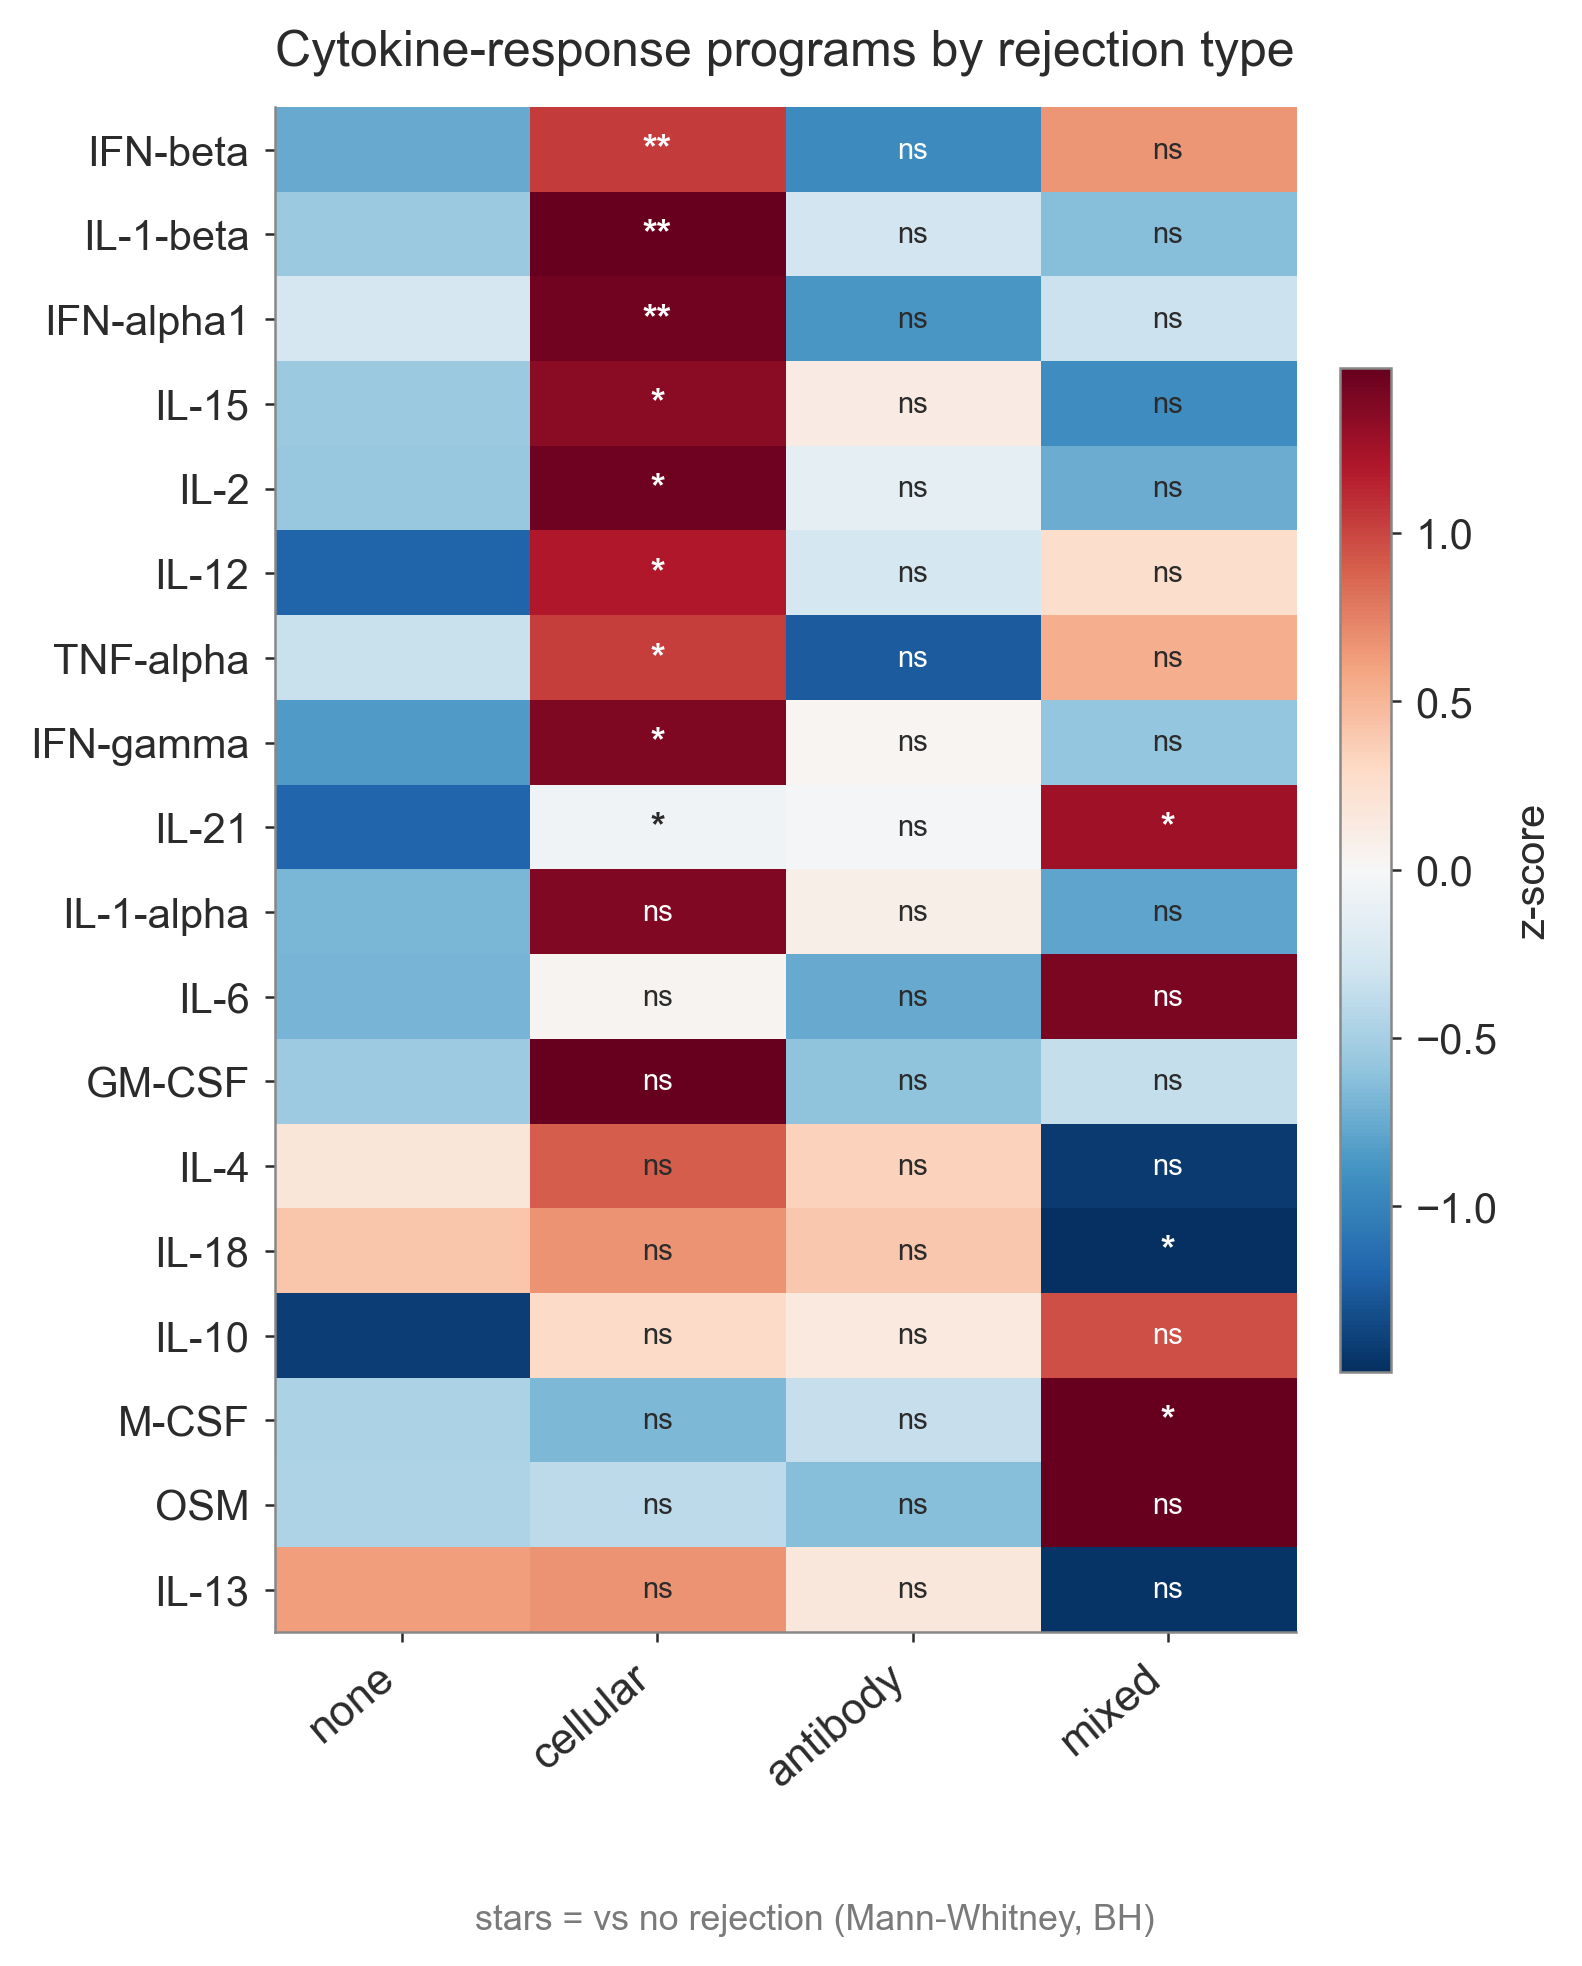

In [6]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from hhca import style as H
from pubfig import save
import fig6_cohort as C

C.apply_style()
c, M, cyto = C.cohort()
S = M[~M.core_neg]
Hb = S.dropna(subset=["rej"] + cyto)
print(f"6h: n={len(Hb)} {Hb.rej.value_counts().to_dict()}")
med = pd.DataFrame({g: Hb[Hb.rej == g][cyto].median() for g in C.REJ4})
Z = med.sub(med.mean(1), axis=0).div(med.std(1).replace(0, np.nan), axis=0)
pv, nm_ = [], []
for k in cyto:
    for g in C.REJ3:
        pv.append(stats.mannwhitneyu(Hb[Hb.rej == g][k], Hb[Hb.rej == "no_rejection"][k]).pvalue)
        nm_.append((k, g))
q = multipletests(pv, method="fdr_bh")[1]
qm = dict(zip(nm_, q))
order = sorted(cyto, key=lambda k: qm[(k, "cellular_rejection")])
Z = Z.loc[order]
print(f"   {int((q < 0.05).sum())}/{len(q)} cells significant vs no rejection")

fig, ax = plt.subplots(figsize=(4.8, 6.6))
vm = float(np.nanmax(np.abs(Z.values)))
im = ax.imshow(Z.values, cmap="RdBu_r", vmin=-vm, vmax=vm, aspect="auto")
ax.set_xticks(range(4))
ax.set_xticklabels(["none", "cellular", "antibody", "mixed"], rotation=40, ha="right")
ax.set_yticks(range(len(order)))
ax.set_yticklabels([k.replace("score_", "") for k in order])
for i, k in enumerate(order):
    for j, g in enumerate(C.REJ3, start=1):
        qq = qm[(k, g)]
        s = "***" if qq < .001 else "**" if qq < .01 else "*" if qq < .05 else "ns"
        ax.text(j, i, s, ha="center", va="center", fontsize=9 if s != "ns" else 7,
                color="white" if abs(Z.values[i, j]) > .62 * vm else H.INK,
                fontweight="bold" if s != "ns" else "normal")
cb = fig.colorbar(im, ax=ax, fraction=.045, pad=.04)
cb.set_label("z-score", fontsize=10)
ax.set_title("Cytokine-response programs by rejection type", fontsize=12, pad=10)
fig.text(.5, -.04, "stars = vs no rejection (Mann-Whitney, BH)", ha="center",
         fontsize=8.6, color=H.MUTED)
save(fig, "Fig6", "h", bbox_inches="tight")


## Fig6 i

Fig 6i — IFN-β programme score by rejection type: Kruskal-Wallis (q = BH over 18 programmes), pairwise MWU brackets (fig6_v9_cytokine_panels.py, IFN-β panel).

Input:
- `see fig6_cohort.py`

Source: `figures/Fig6/panel_i.py`

COHORT: 108 biopsies / 62 patients; core-negative excluded from rejection-labelled panels: 8
IFN-β: Kruskal p=0.000722 q=0.00533 | pairwise q: none vs cellular 0.00082, none vs antibody 0.992, none vs mixed 0.329, cellular vs antibody 0.0303, cellular vs mixed 0.463, antibody vs mixed 0.329


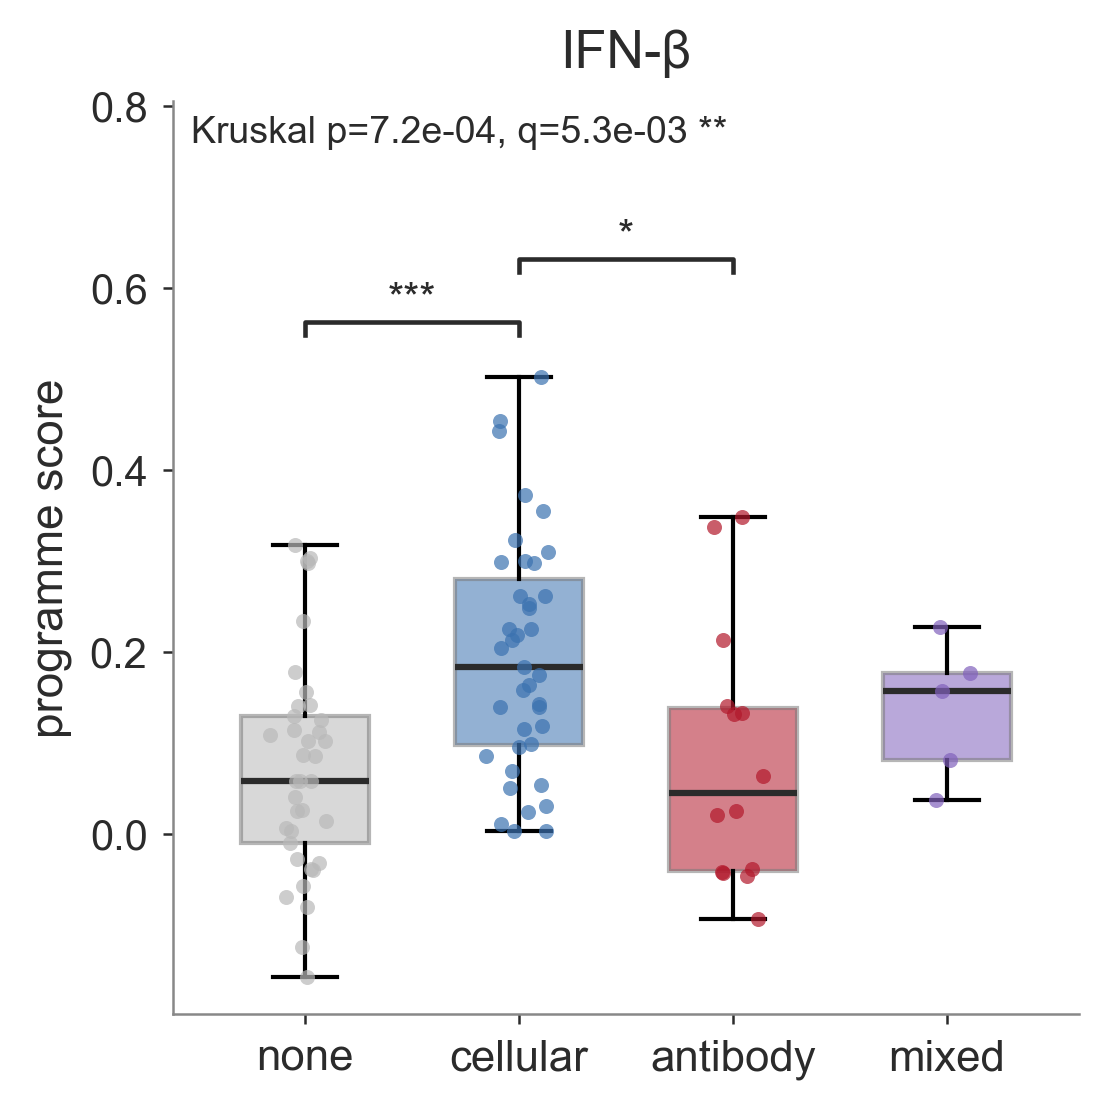

In [7]:
import itertools
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from hhca import style as H
from pubfig import save
import fig6_cohort as C

C.apply_style()
c, M, cyto = C.cohort()
S = M[~M.core_neg]
Hb = S.dropna(subset=["rej"] + cyto)
sizes = {g: int((Hb.rej == g).sum()) for g in C.REJ4}
assert [sizes[g] for g in C.REJ4] == [37, 39, 14, 5] and len(Hb) == 95, "cohort does not reproduce"

prs = list(itertools.combinations(range(4), 2))
vals = {k: [Hb.loc[Hb.rej == g, k].values for g in C.REJ4] for k in cyto}
kp = np.array([stats.kruskal(*vals[k]).pvalue for k in cyto])
kq = multipletests(kp, method="fdr_bh")[1]
KP, KQ = dict(zip(cyto, kp)), dict(zip(cyto, kq))

k = "score_IFN-beta"
v = vals[k]
PQ = multipletests([stats.mannwhitneyu(v[i], v[j]).pvalue for i, j in prs], method="fdr_bh")[1]
print(f"IFN-β: Kruskal p={KP[k]:.3g} q={KQ[k]:.3g} | pairwise q: "
      + ", ".join(f"{C.XLAB[i]} vs {C.XLAB[j]} {q:.3g}" for (i, j), q in zip(prs, PQ)))

fig, ax = plt.subplots(figsize=(3.9, 3.95))
rng = np.random.default_rng(0)
bp = ax.boxplot(v, positions=range(4), widths=.6, patch_artist=True, showfliers=False,
                medianprops=dict(color=H.INK, lw=1.5))
for pt_, g in zip(bp["boxes"], C.REJ4):
    pt_.set_facecolor(C.RCOL[g]); pt_.set_alpha(.55); pt_.set_edgecolor(H.MUTED)
for i, z in enumerate(v):
    ax.scatter(rng.normal(i, .07, len(z)), z, s=13, color=C.RCOL[C.REJ4[i]], alpha=.7, lw=0, zorder=3)
ymx = max(np.max(z) for z in v); ymn = min(np.min(z) for z in v); ry = ymx - ymn
sig = sorted([(i, j, q) for (i, j), q in zip(prs, PQ) if q < .05], key=lambda t: (t[1] - t[0], t[0]))
lvl = 0
for i, j, q_ in sig:
    y = ymx + .07 * ry + lvl * .105 * ry
    ax.plot([i, i, j, j], [y, y + .022 * ry, y + .022 * ry, y], color=H.INK, lw=1.1)
    ax.text((i + j) / 2, y + .028 * ry, H.stars(q_), ha="center", va="bottom", fontsize=10)
    lvl += 1
top_br = ymx + .07 * ry + (max(lvl - 1, 0)) * .105 * ry + (.085 * ry if lvl else 0)
ax.set_ylim(ymn - .06 * ry, max(top_br, ymx + .07 * ry) + .20 * ry)
ax.text(.02, .985, f"Kruskal p={KP[k]:.1e}, q={KQ[k]:.1e} {H.stars(KQ[k])}",
        transform=ax.transAxes, va="top", ha="left", fontsize=9)
ax.set_xlim(-.62, 3.62)
ax.set_xticks(range(4)); ax.set_xticklabels(C.XLAB)
ax.set_title(C.nice(k), fontsize=12.5, pad=8)
ax.set_ylabel("programme score")
for s_ in ("top", "right"):
    ax.spines[s_].set_visible(False)
save(fig, "Fig6", "i", bbox_inches="tight")


## Fig6 j

Fig 6j — IL-4 programme score in CD4 T cells (resting + proliferating, cell-weighted), resolved vs persistence, pre-treatment biopsies (fig6_v9.py).

Input:
- `see fig6_cohort.py`
- `heart_results/rejection_prediction/tables/cytokine_atlas14_scores_perbiopsy.csv`

Source: `figures/Fig6/panel_j.py`

COHORT: 108 biopsies / 62 patients; core-negative excluded from rejection-labelled panels: 8
6j: n=37 {'persistence': 19, 'resolved': 18}
   MWU p=0.0201 AUC=0.73


/var/folders/3d/8h6srt8s5ns3rk6jcv2vcqc00000gn/T/ipykernel_67726/2801609087.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.num.sum() / d.n.sum() if d.n.sum() > 0 else np.nan))


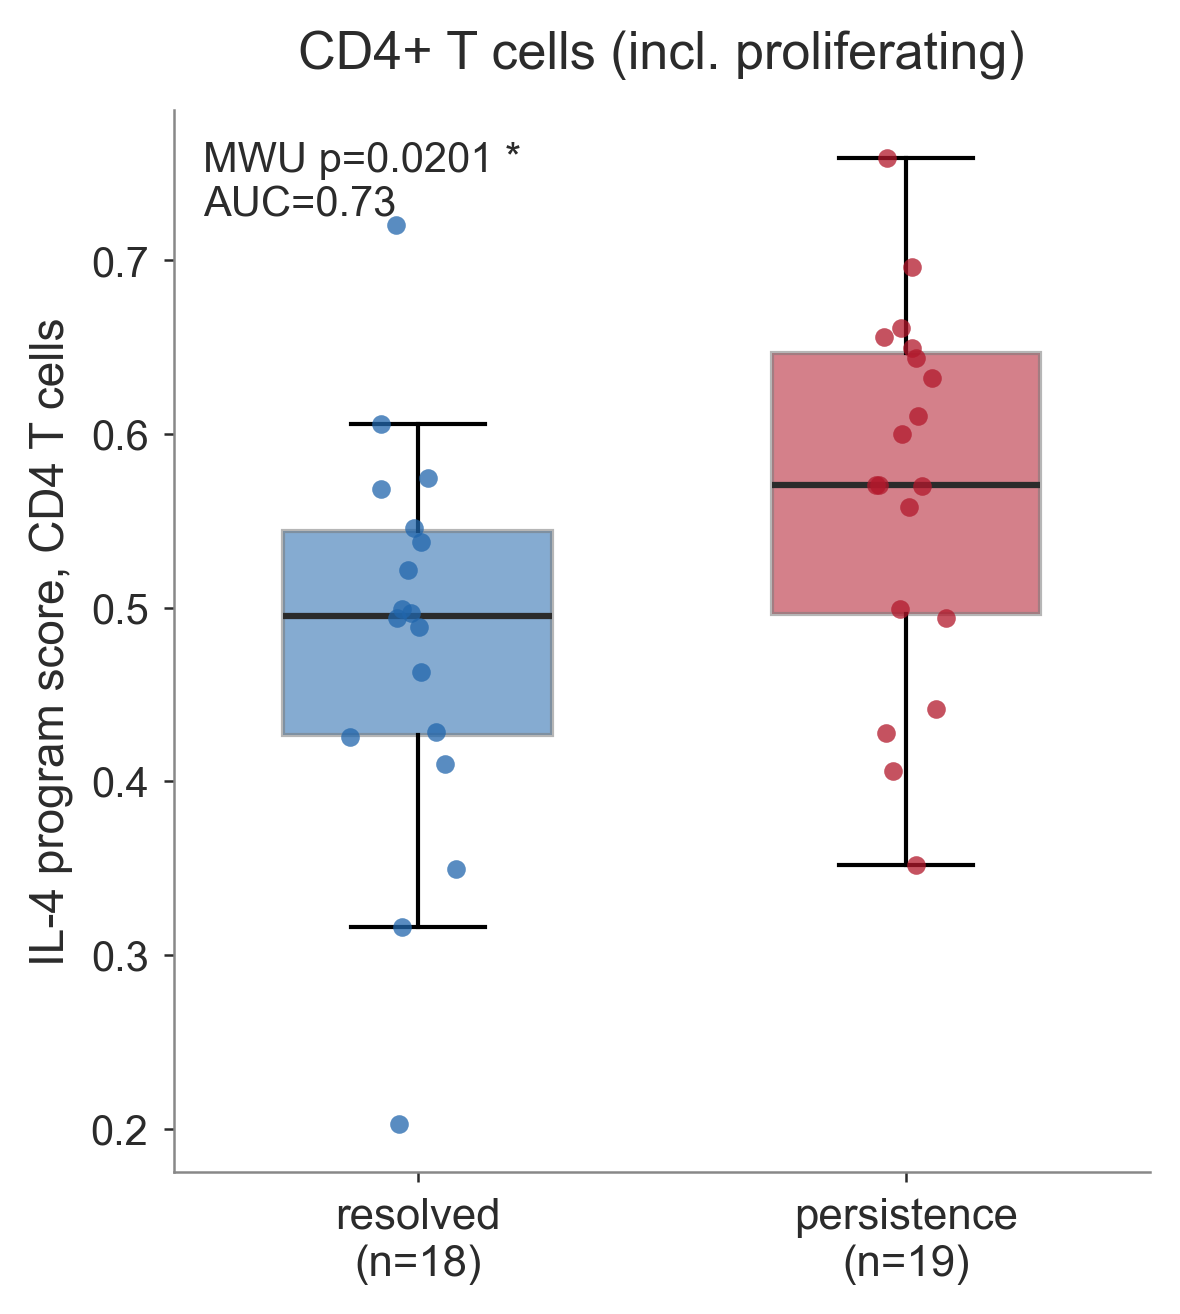

In [8]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from hhca import style as H
from pubfig import save
import fig6_cohort as C

C.apply_style()
c, M, cyto = C.cohort()
mm = C.lymphoid_labels()
s14 = pd.read_csv(C.TAB + "cytokine_atlas14_scores_perbiopsy.csv")
POOL = {"CD4 T": "CD4 T cells", "prolif. CD4 T": "Proliferating CD4 T cells"}
ncell = (mm[mm.label8.isin(POOL.values())].groupby(["Sample", "label8"]).size()
         .rename("n").reset_index())
ncell["ct"] = ncell.label8.map({v: k for k, v in POOL.items()})
w = s14[s14.ct.isin(POOL)][["Sample", "ct", "IL-4"]].merge(ncell[["Sample", "ct", "n"]],
                                                           on=["Sample", "ct"], how="left")
w["n"] = w.n.fillna(0)
il4 = (w.assign(num=w["IL-4"] * w.n).groupby("Sample")
       .apply(lambda d: d.num.sum() / d.n.sum() if d.n.sum() > 0 else np.nan))
jb = c[["bxid"]].join(il4.rename("il4")).dropna().groupby("bxid").il4.mean()
J = M.join(jb.rename("il4"))
J = J[(J.timing == "pre") & (J.epi.isin(C.REJ3))].dropna(subset=["il4", "res"])
print(f"6j: n={len(J)} {J.res.value_counts().to_dict()}")
vv = [J[J.res == g].il4.values for g in ["resolved", "persistence"]]
u = stats.mannwhitneyu(vv[1], vv[0], alternative="two-sided")
auc = u.statistic / (len(vv[0]) * len(vv[1]))
print(f"   MWU p={u.pvalue:.3g} AUC={auc:.2f}")

fig, ax = plt.subplots(figsize=(4.2, 4.6))
rng = np.random.default_rng(0)
bp = ax.boxplot(vv, positions=[0, 1], widths=.55, patch_artist=True, showfliers=False,
                medianprops=dict(color=H.INK, lw=1.5))
for pt_, g in zip(bp["boxes"], ["resolved", "persistence"]):
    pt_.set_facecolor(C.RES[g]); pt_.set_alpha(.55); pt_.set_edgecolor(H.MUTED)
for i, z in enumerate(vv):
    ax.scatter(rng.normal(i, .06, len(z)), z, s=20,
               color=C.RES[["resolved", "persistence"][i]], alpha=.75, lw=0, zorder=3)
ax.set_xticks([0, 1])
ax.set_xticklabels([f"resolved\n(n={len(vv[0])})", f"persistence\n(n={len(vv[1])})"])
ax.set_ylabel("IL-4 program score, CD4 T cells")
ax.text(.03, .97, f"MWU p={u.pvalue:.3g} {H.stars(u.pvalue)}\nAUC={auc:.2f}",
        transform=ax.transAxes, va="top", fontsize=10)
ax.set_title("CD4+ T cells (incl. proliferating)", fontsize=12.5, pad=10)
for s_ in ("top", "right"):
    ax.spines[s_].set_visible(False)
save(fig, "Fig6", "j", bbox_inches="tight")


## Fig6 k

Fig 6k — immunosuppressant drug-target score by cell type (lymphoid at Level 4), z-scored per drug across 18 cell types (generator lost; method of manuscript_restyle/Fig6/code/panel_kl.py on the Level-4 classes).

Input:
- `storage/rejection_GSE290577/extracted/{counts.mtx,genes.txt,barcodes.txt}`
- `heart_results/rejection_prediction/tables/{xenium_atlas_labels,xenium_lymphoid8_annotation}.csv`

Source: `figures/Fig6/panel_k.py`

/opt/homebrew/Cellar/python@3.11/3.11.15_1/Frameworks/Python.framework/Versions/3.11/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


adata (162638, 477)


cells per column: {'CD8 T': 11222, 'prolif. CD8 T': 3714, 'CD4 T': 5775, 'prolif. CD4 T': 1488, 'Treg': 1199, 'prolif. Treg': 366, 'NK': 2691, 'prolif. NK': 1025, 'Macrophages': 9378, 'Monocytes': 11018, 'Dendritic cells': 6770, 'B cells': 5377, 'Plasma cells': 5196, 'Mast cells': 2258, 'Endothelial': 33630, 'Fibroblasts': 11438, 'Mural': 11726, 'Cardiomyocytes': 27978}
z range -2.23 3.69


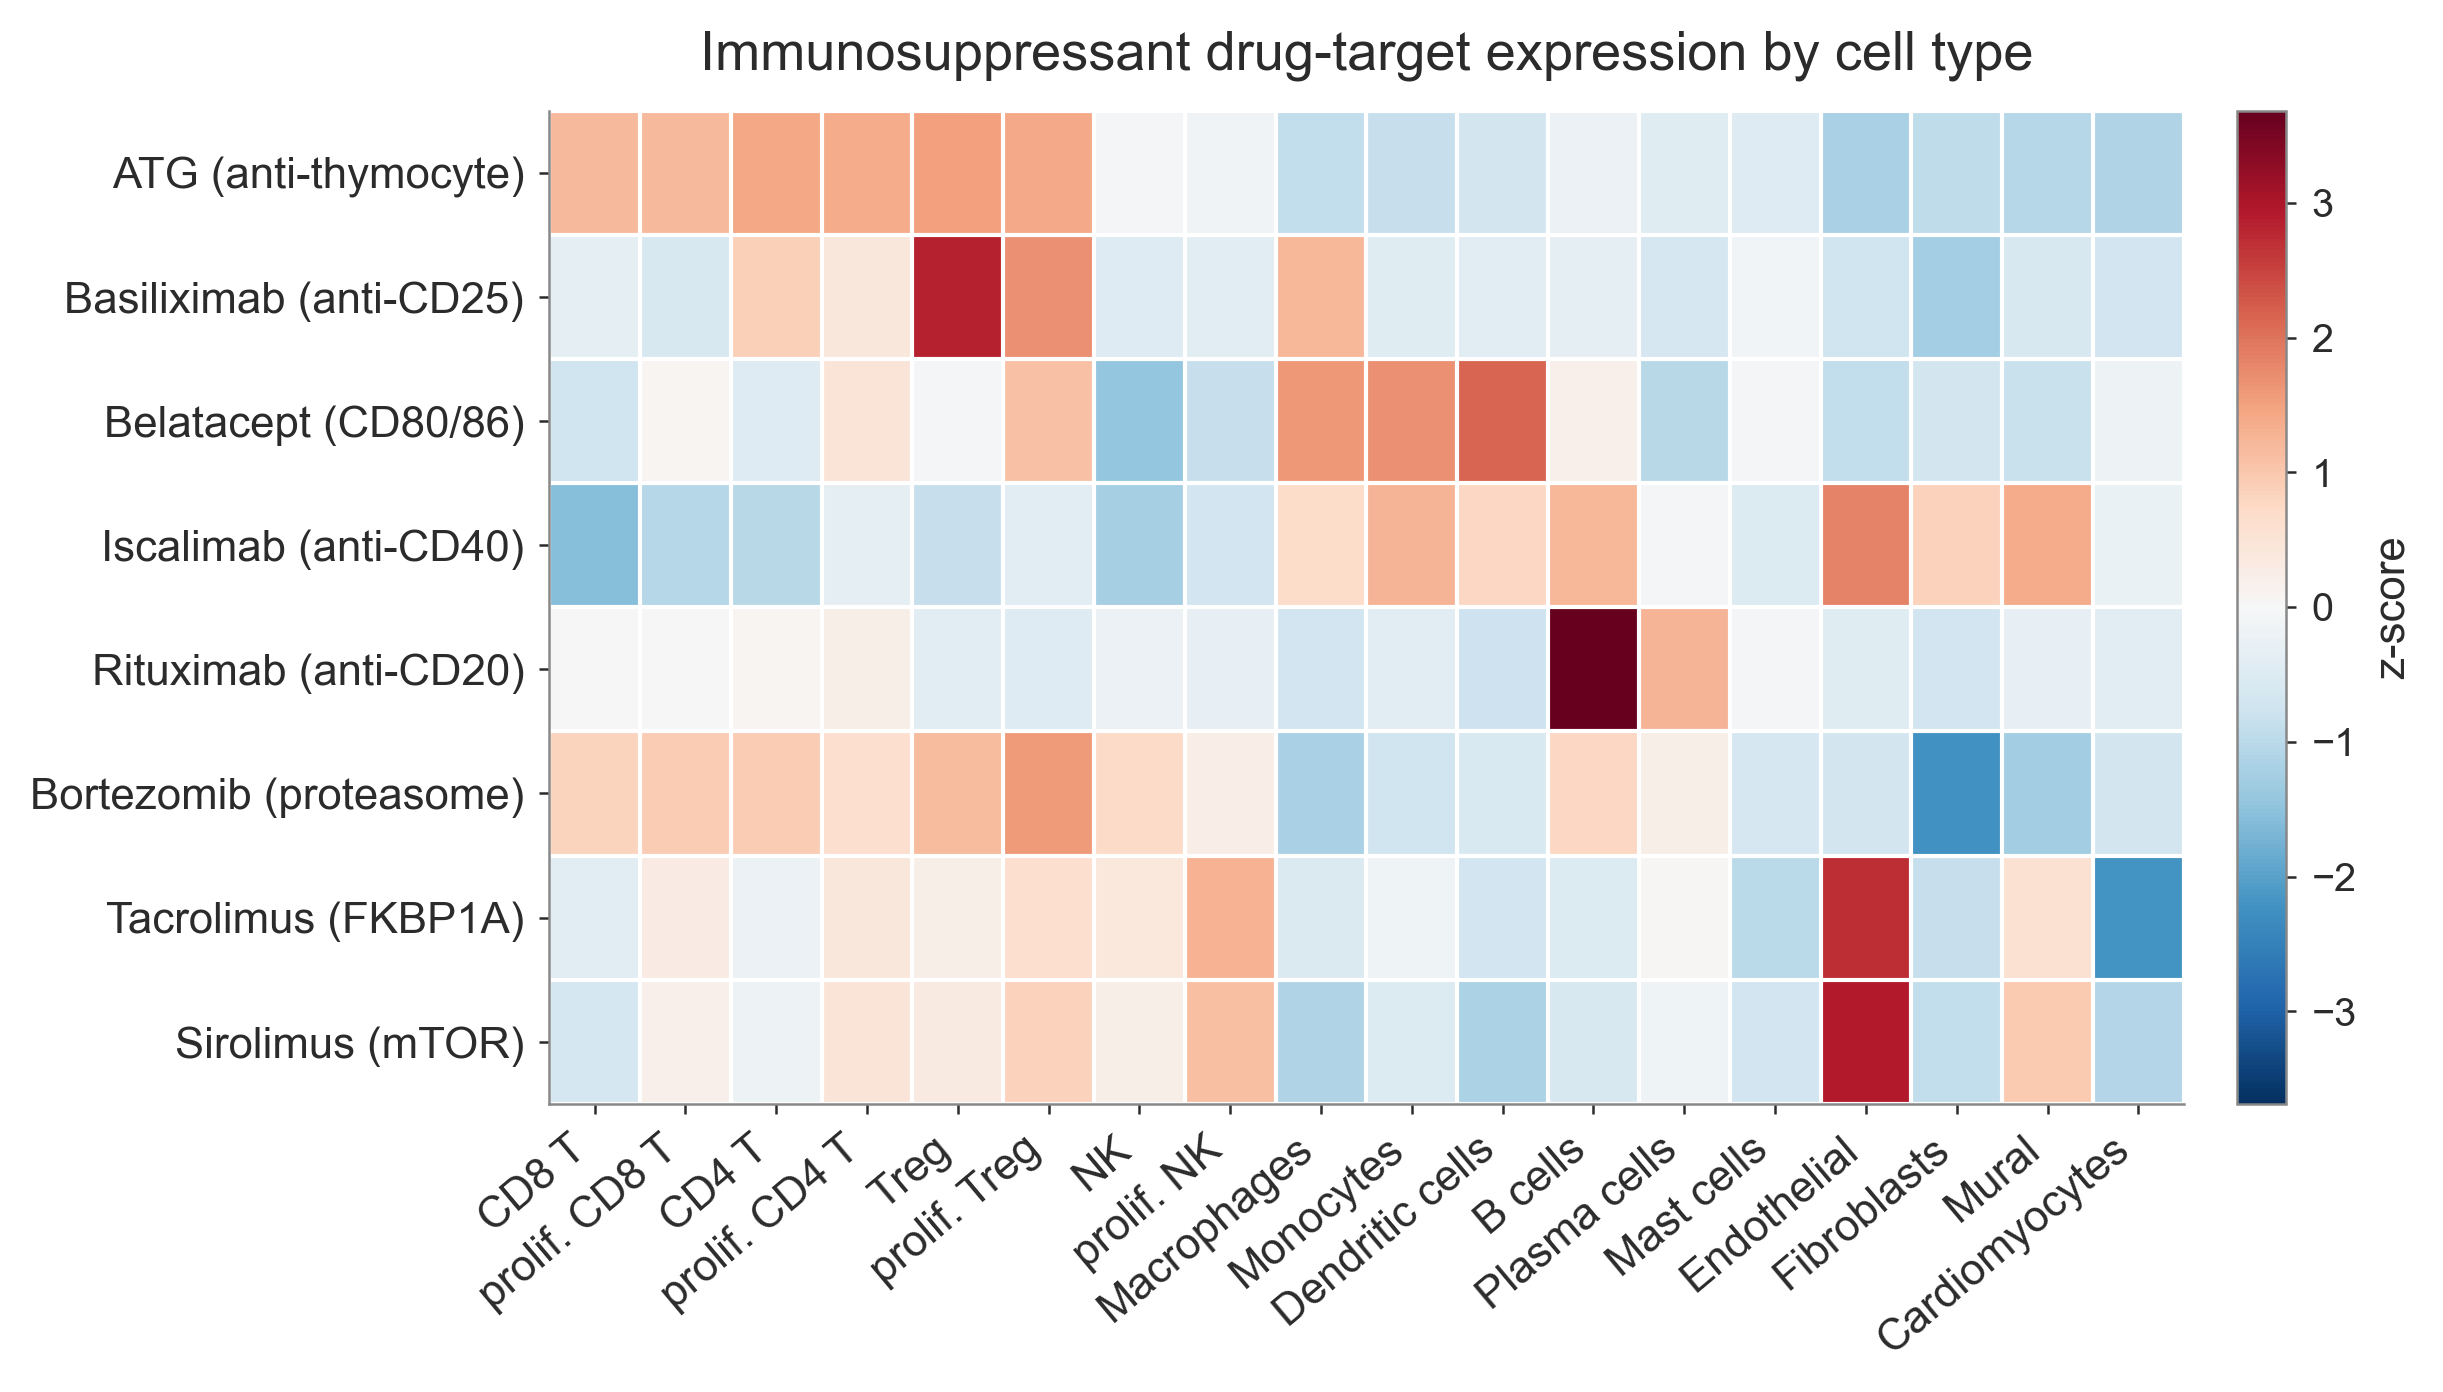

In [9]:
import numpy as np
import pandas as pd
import scipy.io
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
from hhca.paths import TABLES
from hhca import style as H
from pubfig import save

H.apply()
mpl.rcParams.update({"axes.titlesize": 13, "axes.labelsize": 11, "xtick.labelsize": 10.5, "ytick.labelsize": 10.5})
EX = f"{TABLES}/storage/rejection_GSE290577/extracted/"
TAB = f"{TABLES}/heart_results/rejection_prediction/tables/"

M = scipy.io.mmread(EX + "counts.mtx").tocsr()
X = M.T.tocsr()
genes = [g.strip() for g in open(EX + "genes.txt")]
bc = [b.strip() for b in open(EX + "barcodes.txt")]
lab = pd.read_csv(TAB + "xenium_atlas_labels.csv", usecols=["cell_id", "Sample", "atlas_L3"]).set_index("cell_id").reindex(bc)
l8 = pd.read_csv(TAB + "xenium_lymphoid8_annotation.csv", usecols=["cell_id", "label8"]).set_index("cell_id").reindex(bc)
obs = lab.reset_index()
obs["label8"] = l8["label8"].values
ad = sc.AnnData(X=X, obs=obs, var=pd.DataFrame(index=genes))
sc.pp.normalize_total(ad, target_sum=1e4)
sc.pp.log1p(ad)
print("adata", ad.shape)

DRUGS = {
    "ATG (anti-thymocyte)": ["CD2", "CD3D", "CD3E", "CD247", "CD5", "CD4", "CD8A", "CD27", "CD28"],
    "Basiliximab (anti-CD25)": ["IL2RA"],
    "Belatacept (CD80/86)": ["CD80", "CD86"],
    "Iscalimab (anti-CD40)": ["CD40"],
    "Rituximab (anti-CD20)": ["MS4A1"],
    "Bortezomib (proteasome)": ["PSMB8"],
    "Tacrolimus (FKBP1A)": ["FKBP1A"],
    "Sirolimus (mTOR)": ["MTOR", "FKBP1A"],
}
DRUGS = {k: [g for g in v if g in ad.var_names] for k, v in DRUGS.items()}
L8MAP = {"CD8 T cells": "CD8 T", "Proliferating CD8 T cells": "prolif. CD8 T",
         "CD4 T cells": "CD4 T", "Proliferating CD4 T cells": "prolif. CD4 T",
         "Tregs": "Treg", "Proliferating Tregs": "prolif. Treg",
         "NK cells": "NK", "Proliferating NK cells": "prolif. NK"}
CTMAP = {"Macrophages": "Macrophages", "Monocytes": "Monocytes", "Dendritic cells": "Dendritic cells",
         "B cells": "B cells", "Plasma Cells": "Plasma cells", "Mast cells": "Mast cells",
         "Arterial Endothelial cells": "Endothelial", "Capillary Endothelial cells": "Endothelial",
         "Venous Endothelial cells": "Endothelial", "Endocardial Endothelial Cells": "Endothelial",
         "Lymphatic Endothelial Cells": "Endothelial", "Fibroblasts": "Fibroblasts",
         "Ventricular Cardiomyocytes": "Cardiomyocytes", "Atrial Cardiomyocytes": "Cardiomyocytes",
         "Pericytes": "Mural", "Vascular Smooth Muscle cells": "Mural"}
ad.obs["ct_group"] = np.where(ad.obs.label8.notna(), ad.obs.label8.map(L8MAP), ad.obs.atlas_L3.map(CTMAP))
COLS = ["CD8 T", "prolif. CD8 T", "CD4 T", "prolif. CD4 T", "Treg", "prolif. Treg", "NK", "prolif. NK",
        "Macrophages", "Monocytes", "Dendritic cells", "B cells", "Plasma cells", "Mast cells",
        "Endothelial", "Fibroblasts", "Mural", "Cardiomyocytes"]
for dname, gset in DRUGS.items():
    sc.tl.score_genes(ad, gset, score_name=f"d_{dname}", ctrl_size=50, random_state=0)
rows = list(DRUGS)
Mmat = np.zeros((len(rows), len(COLS)))
for i, dname in enumerate(rows):
    mean_by = ad.obs.groupby("ct_group", observed=True)[f"d_{dname}"].mean()
    for j, c in enumerate(COLS):
        Mmat[i, j] = mean_by.get(c, np.nan)
Z = (Mmat - np.nanmean(Mmat, axis=1, keepdims=True)) / (np.nanstd(Mmat, axis=1, keepdims=True) + 1e-9)
print("cells per column:", ad.obs.ct_group.value_counts().reindex(COLS).to_dict())
print("z range", Z.min().round(2), Z.max().round(2))

vmax = np.nanmax(np.abs(Z))
fig, ax = plt.subplots(figsize=(7.6, 4.3))
im = ax.imshow(Z, aspect="auto", cmap=H.DIVERGING, vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(COLS))); ax.set_xticklabels(COLS, rotation=40, ha="right")
ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows)
ax.set_xticks(np.arange(-.5, len(COLS), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(rows), 1), minor=True)
ax.grid(which="minor", color="white", lw=1.0); ax.tick_params(which="minor", length=0)
ax.set_title("Immunosuppressant drug-target expression by cell type", fontsize=13, pad=10)
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
cb.set_label("z-score", fontsize=10.5); cb.ax.tick_params(labelsize=9.5)
save(fig, "Fig6", "k", bbox_inches="tight")


## Fig6 l1, l2

Fig 6l — ATG drug-target score vs immune fraction (l1) and vs T-cell fraction (l2), all 108 biopsies, coloured by ISHLT grade (fig6_v9.py).

Input:
- `see fig6_cohort.py`

Source: `figures/Fig6/panel_l.py`

COHORT: 108 biopsies / 62 patients; core-negative excluded from rejection-labelled panels: 8
6l1: n=108 rho=0.89 p=2.75e-37
6l2: n=108 rho=0.90 p=8.66e-40


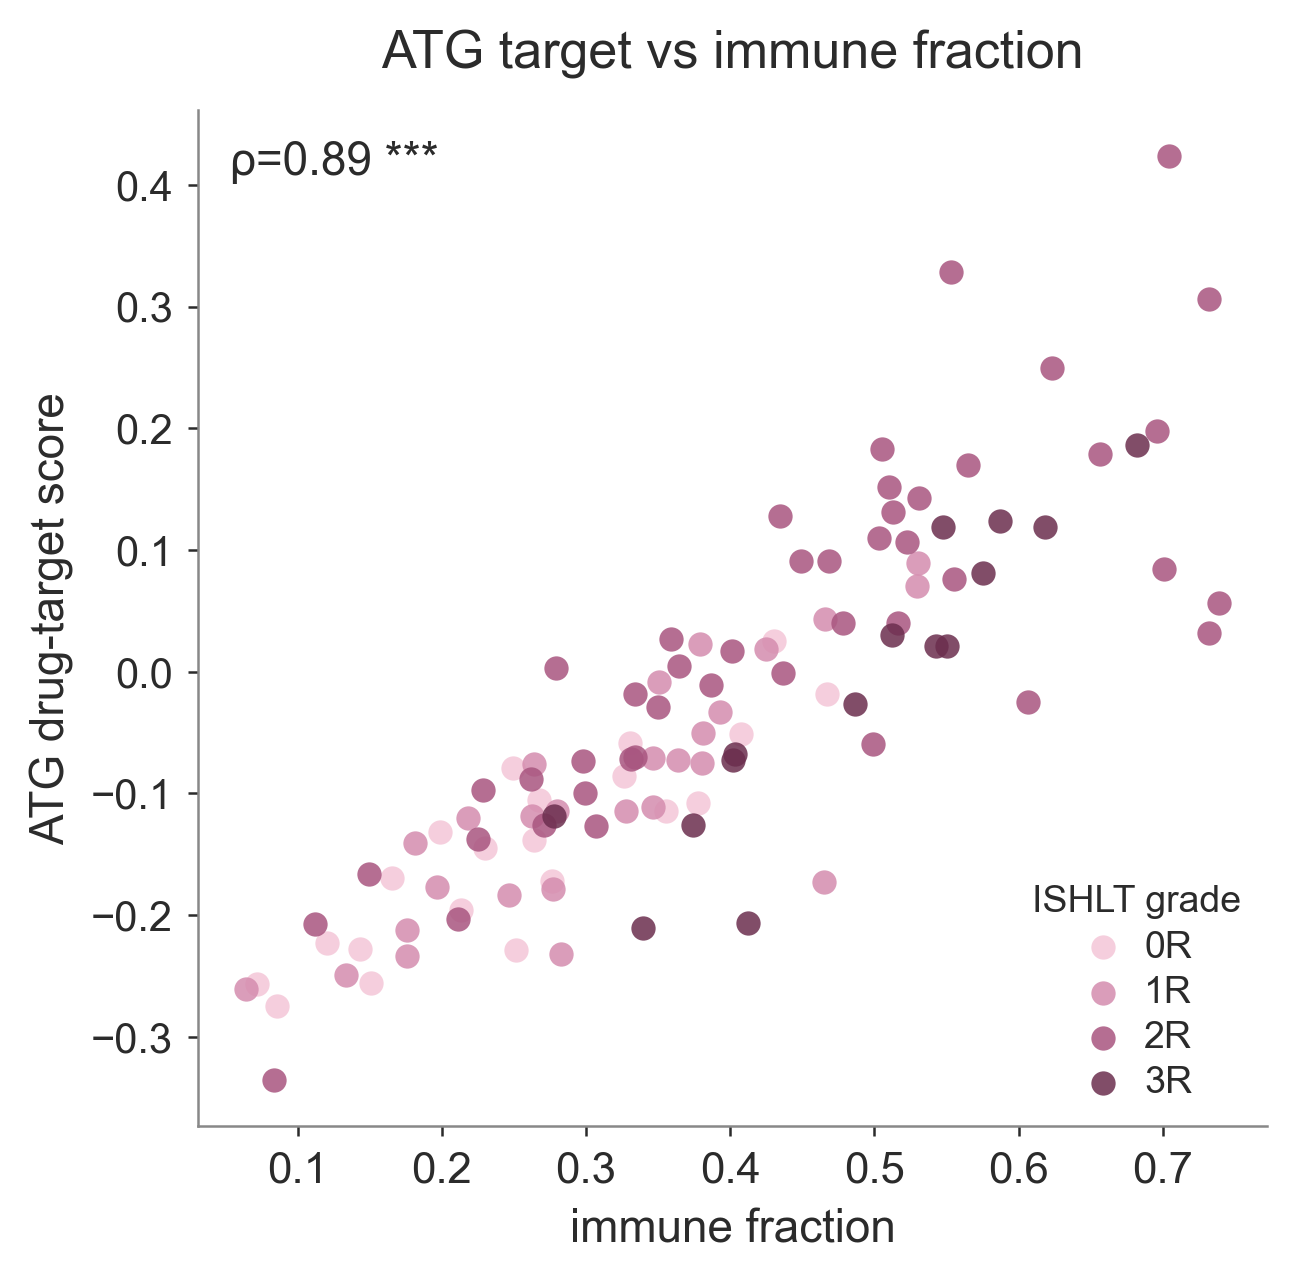

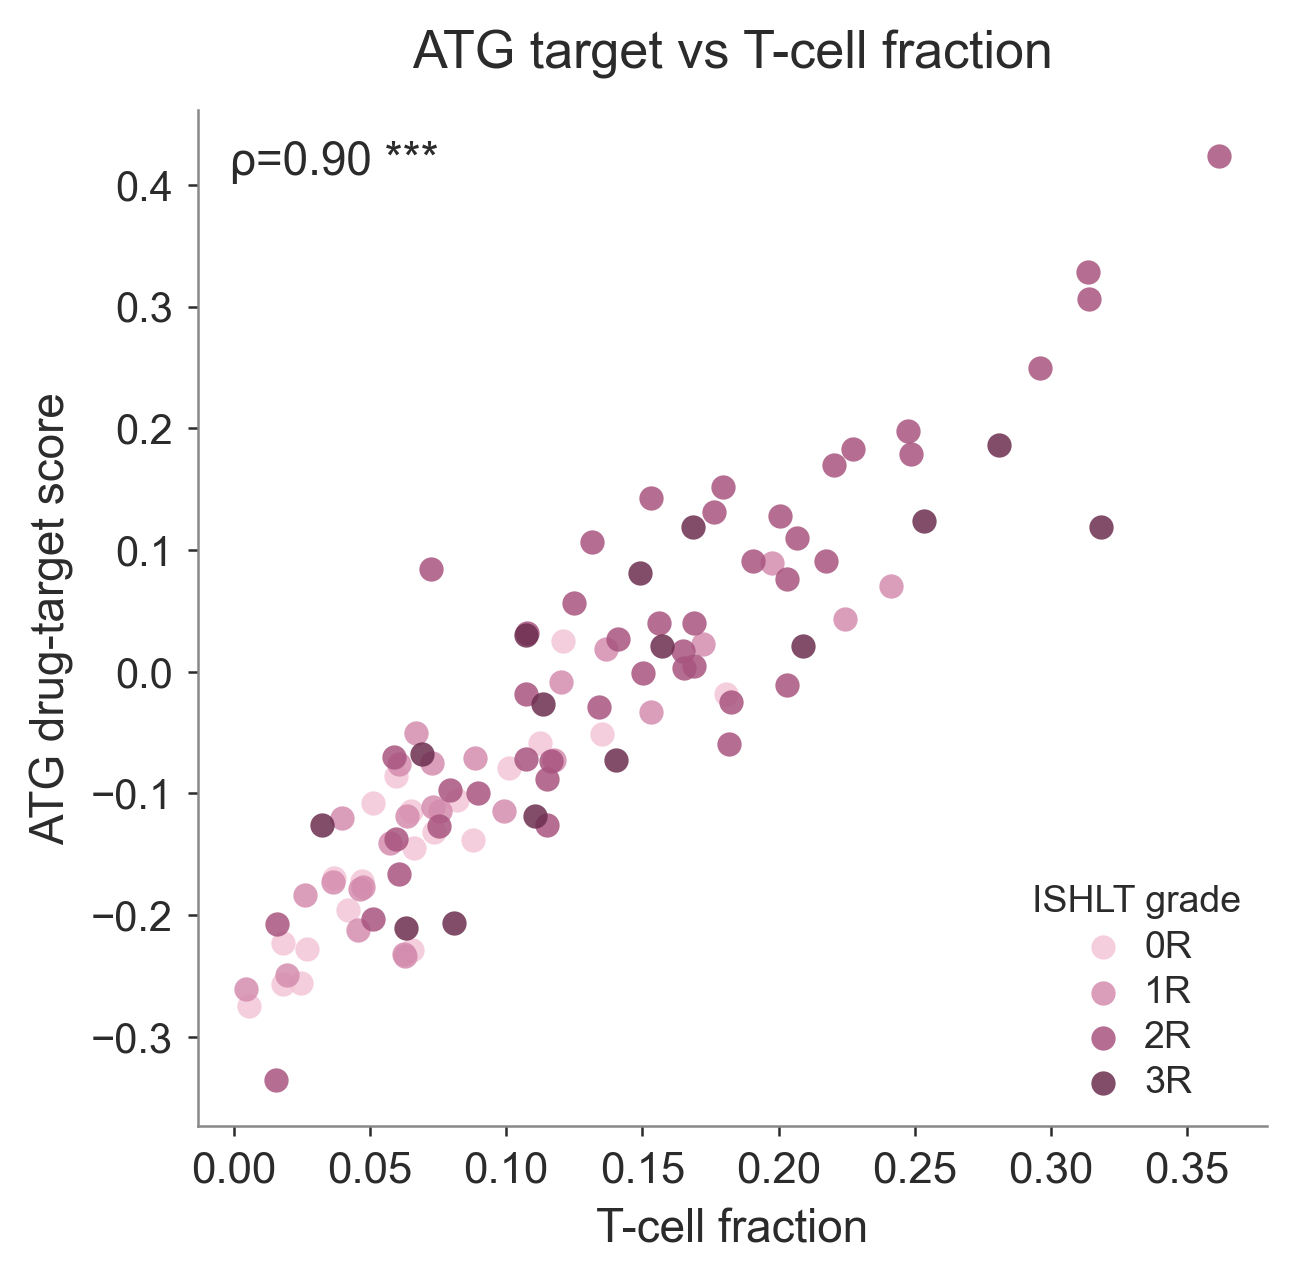

In [10]:
from scipy import stats
import matplotlib.pyplot as plt
from hhca import style as H
from pubfig import save
import fig6_cohort as C

C.apply_style()
c, M, cyto = C.cohort()
for xc, xl, tag in [("immf", "immune fraction", "l1"), ("tf", "T-cell fraction", "l2")]:
    L = M.dropna(subset=[xc, "atg"])
    rho, p_ = stats.spearmanr(L[xc], L.atg)
    print(f"6{tag}: n={len(L)} rho={rho:.2f} p={p_:.3g}")
    fig, ax = plt.subplots(figsize=(4.6, 4.4))
    for g in sorted(L.grade.dropna().unique()):
        s = L[L.grade == g]
        ax.scatter(s[xc], s.atg, s=34, color=C.GRC.get(int(g), "#CCC"), alpha=.85,
                   linewidths=0, label=f"{int(g)}R")
    ax.set_xlabel(xl)
    ax.set_ylabel("ATG drug-target score")
    ax.text(.03, .97, f"ρ={rho:.2f} {H.stars(p_)}", transform=ax.transAxes, va="top", fontsize=11)
    ax.set_title(f"ATG target vs {xl}", fontsize=12.5, pad=10)
    ax.legend(frameon=False, fontsize=9, title="ISHLT grade", title_fontsize=9, loc="lower right")
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
    save(fig, "Fig6", tag, bbox_inches="tight")
